# ¿Dónde debe abrir McDonald's sus próximas sucursales en México?

## Clasificación de municipios con el DENUE 2026 y el Censo de Población y Vivienda 2020

**Autor:** Diego Jiménez González

**Módulo IV – Minería de Datos** · Diplomado en Técnicas Estadísticas y Minería de Datos · FES Acatlán, UNAM · Septiembre de 2026

---

### Resumen ejecutivo

McDonald's opera más de 380 sucursales en México y busca llegar a 400. Este proyecto construye una criba
nacional para decidir **dónde abrir**, con datos públicos de INEGI:

- el **DENUE de mayo de 2026**: 806,496 establecimientos de preparación de alimentos y alojamiento;
- el **Censo de Población y Vivienda 2020**: 2,469 municipios.

**Qué se hizo**

- **Identificación.** Se ubicaron 417 sucursales de la marca en 123 municipios. Entre ellas están las de un
  franquiciatario de Michoacán que registra sus restaurantes sin la marca, detectado al contrastar el modelo
  con fuentes externas.
- **Perfil de cada municipio.** Se describió con 15 variables: demanda, poder adquisitivo, empleo, sector
  restaurantero y competencia.
- **Modelo.** Un random forest distingue a los municipios con McDonald's con un **AUC de 0.988** en el
  conjunto de prueba, y de 0.922 entre las 235 ciudades de 100 mil habitantes o más.

**El perfil de un municipio McDonald's:**

- más de ~125 mil habitantes;
- al menos tres cadenas rivales;
- internet en más del 46 % de las viviendas;
- un sector restaurantero con empleo formal.

**Resultado.** De los 20 municipios con mayor probabilidad que no tienen sucursal en el DENUE:

- **5 ya tienen un McDonald's** según el sitio oficial de la marca. Apodaca, por ejemplo, abrió en noviembre
  de 2025, y ninguna de las cinco aparece aún en el directorio. El modelo reconoce los mercados donde la
  empresa ya está creciendo.
- **13 son las oportunidades depuradas**, encabezadas por Tepic (capital de 426 mil habitantes a 92 km de la
  sucursal más cercana), Corregidora, Manzanillo y Villa de Álvarez.
- **2 quedan como no concluyentes.**

La recomendación es llevar las 13 oportunidades a estudio de sitio, con una advertencia: la marca cerró su
restaurante de la ciudad de Colima en 2025.

### Estructura del proyecto

El documento sigue la especificación del proyecto y el ciclo CRISP-DM (*Cross Industry Standard Process for
Data Mining*). Recorre el proceso KDD completo: integración, selección, limpieza, transformación, minería,
evaluación de patrones y presentación del conocimiento.

| Sección | Requerimiento | Fase CRISP-DM |
|---|---|---|
| 1. Análisis del negocio | Pregunta a responder (hipótesis), escenario a desarrollar, análisis de variables de negocio | Comprensión del negocio |
| 2. Entendimiento de los datos | Datos origen (diccionario), proceso ETL, limpieza y transformación, estadística descriptiva | Comprensión y preparación de los datos |
| 3. Modelado analítico | Algoritmo, parámetros de configuración, datos de entrenamiento y de prueba, resultados y evaluación | Modelado y evaluación |
| 4. Consideraciones del modelo | Beneficios, limitaciones y supuestos | Evaluación |
| 5. Conclusiones | Respuesta a la hipótesis y recomendación | Despliegue |

El análisis avanza por los cuatro niveles de madurez analítica:

1. **Descriptivo.** ¿Qué municipios tienen McDonald's?
2. **Diagnóstico.** ¿En qué se distinguen de los demás?
3. **Predictivo.** ¿Qué municipios sin sucursal tienen ese mismo perfil?
4. **Prescriptivo.** ¿En qué orden conviene estudiarlos para abrir?

---
## 0. Configuración del entorno

Todas las rutas son relativas a la raíz del repositorio. Los datos crudos se leen directamente desde los ZIP
de INEGI en `datos/crudos/` (se descargan si no existen). Cada figura se guarda en `figuras/` y las tablas
intermedias y finales en `datos/procesados/` y `datos/analiticos/`.

In [1]:
import sys
import re
import zipfile
import hashlib
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import scipy
from scipy import stats
from scipy.spatial import cKDTree
import sklearn
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from IPython.display import display

RAIZ = Path.cwd()
CRUDOS = RAIZ / "datos" / "crudos"
PROCESADOS = RAIZ / "datos" / "procesados"
ANALITICOS = RAIZ / "datos" / "analiticos"
FIGURAS = RAIZ / "figuras"
for carpeta in (CRUDOS, PROCESADOS, ANALITICOS, FIGURAS):
    carpeta.mkdir(parents=True, exist_ok=True)

SEMILLA = 42
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)

print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · numpy {np.__version__} · "
      f"scikit-learn {sklearn.__version__} · scipy {scipy.__version__} · matplotlib {matplotlib.__version__}")

Python 3.13.1 · pandas 3.0.3 · numpy 2.4.6 · scikit-learn 1.9.1 · scipy 1.18.0 · matplotlib 3.11.0


In [2]:
# ---- Estilo de las gráficas ----------------------------------------------------------------
# Tonos categóricos validados para daltonismo; el gris marca el contexto (municipios sin McDonald's).
AZUL, NARANJA, AQUA, AMARILLO, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
GRIS = "#c3c2b7"
TINTA, TINTA_2, TENUE = "#0b0b0b", "#52514e", "#898781"
REJILLA, FONDO = "#e1e0d9", "#ffffff"
CMAP_DIV = LinearSegmentedColormap.from_list("azul_gris_rojo", [AZUL, "#f0efec", "#e34948"])
CMAP_SEC = LinearSegmentedColormap.from_list("azules", ["#f0f6fe", "#86b6ef", "#2a78d6", "#0d366b"])
COLOR_BLOQUE = {"Demanda": AZUL, "Poder adquisitivo": NARANJA, "Empleo": AQUA,
                "Sector y turismo": AMARILLO, "Competencia": MAGENTA}

plt.rcParams.update({
    "font.family": "Arial", "font.size": 10,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelsize": 10, "axes.labelcolor": TINTA_2, "axes.edgecolor": GRIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": GRIS, "ytick.color": GRIS, "xtick.labelcolor": TINTA_2, "ytick.labelcolor": TINTA_2,
    "text.color": TINTA, "grid.color": REJILLA, "grid.linewidth": 0.8,
    "figure.facecolor": FONDO, "axes.facecolor": FONDO, "legend.frameon": False,
    "savefig.dpi": 200, "savefig.bbox": "tight", "savefig.facecolor": FONDO,
})

_figura = 0


def nueva_figura(titulo, tam=(8.5, 4.6)):
    """Crea una figura con una sola gráfica y su título numerado."""
    global _figura
    _figura += 1
    fig, ax = plt.subplots(figsize=tam)
    ax.set_title(f"Figura {_figura}: {titulo}")
    return fig, ax


def guardar(fig, nombre):
    """Guarda la figura en figuras/ con su número y la muestra."""
    fig.savefig(FIGURAS / f"fig{_figura:02d}_{nombre}.png")
    plt.show()
    plt.close(fig)


def km_entre(lat1, lon1, lat2, lon2):
    """Distancia de gran círculo en kilómetros (admite arreglos)."""
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

---
## 1. Análisis del negocio

### 1.1 Pregunta a responder (hipótesis)

**Pregunta de negocio.** ¿En qué municipios de México que hoy no tienen un McDonald's existe un mercado con el
mismo perfil que el de los municipios donde la marca ya opera?

**Hipótesis (H1).** La presencia de McDonald's en un municipio no es aleatoria: se explica por cinco factores
que se pueden medir con datos públicos:

- el tamaño y la urbanización del mercado (**demanda**);
- el **poder adquisitivo** de los hogares;
- el **empleo** formal;
- la actividad del **sector de alimentos y del turismo**;
- la presencia de **cadenas competidoras**.

Si H1 es cierta, un modelo de clasificación entrenado con esos factores distingue a los municipios con y sin
sucursal. Los municipios sin sucursal a los que el modelo asigna una probabilidad alta son oportunidades de
expansión.

**Hipótesis nula (H0).** Los factores no distinguen a los municipios con McDonald's de los demás: el modelo no
supera de forma relevante a una asignación al azar (AUC ≈ 0.5).

**Criterios de decisión, fijados antes de modelar.** H1 se sostiene si se cumplen los tres:

1. El mejor modelo alcanza un **AUC ≥ 0.80 en el conjunto de prueba**.
2. Las variables de **demanda y poder adquisitivo** están entre las más importantes del modelo.
3. Los municipios con y sin McDonald's difieren de forma significativa (prueba U de Mann-Whitney,
   α = 0.05) en la mayoría de las variables.

### 1.2 Escenario a desarrollar

McDonald's opera en México a través de Arcos Dorados, su franquiciatario maestro en América Latina. En agosto
de 2026 la operación rebasaba las **380 sucursales en el país**, con la meta de acercarse a **400**, y la
compañía ya usa una plataforma digital para identificar ubicaciones (Expansión, 14 de agosto de 2026).

**Escenario.** El equipo de expansión debe decidir dónde abrir **alrededor de 20 sucursales nuevas**. Antes de
invertir en estudios de sitio (aforos, predios, rentas, permisos), necesita una primera criba nacional, a nivel
municipal, hecha con datos públicos y reproducibles.

| Elemento | Definición |
|---|---|
| Usuario del análisis | Dirección de expansión y desarrollo inmobiliario |
| Decisión que apoya | En qué municipios iniciar estudios de ubicación |
| Unidad de análisis | Municipio (2,469 municipios del Marco Geoestadístico 2020) |
| Entregable | Lista priorizada de municipios sin McDonald's, con su probabilidad y su perfil |
| Fuera de alcance | La ubicación exacta dentro del municipio y la rentabilidad de cada sitio |

La lista distingue dos tipos de oportunidad:

- **Densificación.** Municipios sin sucursal dentro de una zona metropolitana donde la marca ya opera.
- **Mercado nuevo.** Ciudades medias lejos de la sucursal más cercana.

### 1.3 Análisis de variables de negocio

Cada factor de la hipótesis se traduce en variables medibles. La tabla resume qué se mide, de dónde viene y qué
efecto se espera sobre la probabilidad de que el municipio tenga un McDonald's.

| Factor | Variable | Fuente | Efecto esperado | Razón de negocio |
|---|---|---|---|---|
| Demanda | `poblacion` | Censo 2020 | + | Un restaurante de autoservicio necesita un volumen mínimo de clientes |
| Demanda | `pct_urbana` | Censo 2020 | + | El formato es urbano: concentra tráfico peatonal y vehicular |
| Demanda | `pct_jovenes` | Censo 2020 | + | La población de 18 a 24 años es el segmento que más consume comida rápida |
| Poder adquisitivo | `escolaridad` | Censo 2020 | + | Aproxima el ingreso: más años de estudio, más gasto en alimentos fuera del hogar |
| Poder adquisitivo | `pct_viv_auto` | Censo 2020 | + | El servicio en auto (AutoMac) y las plazas comerciales dependen del automóvil |
| Poder adquisitivo | `pct_viv_internet` | Censo 2020 | + | Aproxima el ingreso y el uso de pedidos por aplicación y entrega a domicilio |
| Empleo | `tasa_participacion` | Censo 2020 | + | Más población con ingreso laboral |
| Empleo | `pct_seguridad_social` | Censo 2020 | + | La afiliación al IMSS o al ISSSTE aproxima el empleo formal y el ingreso estable |
| Empleo | `empleo_restaurantes_1k` | DENUE 2026 | + | Mercado laboral del sector: capacidad de contratar personal con experiencia |
| Sector y turismo | `restaurantes_10k` | DENUE 2026 | + / − | Densidad de oferta: mercado probado o saturado |
| Sector y turismo | `pct_rest_11mas` | DENUE 2026 | + | Proporción de restaurantes medianos y grandes: formalidad del sector |
| Sector y turismo | `hoteles_10k` | DENUE 2026 | + | Turismo: demanda de visitantes además de la de residentes |
| Sector y turismo | `plazas_comerciales` | DENUE 2026 | + | Buena parte de las sucursales opera dentro de centros y plazas comerciales |
| Competencia | `sucursales_competencia` | DENUE 2026 | + | Donde operan las cadenas rivales, el mercado ya está validado |
| Competencia | `marcas_competencia` | DENUE 2026 | + | Número de cadenas rivales distintas presentes (de 8) |

**Variable objetivo:** `tiene_mcdonalds` (1 si el municipio tiene al menos una sucursal, 0 si no).

El censo no pregunta el ingreso de los hogares, por lo que el poder adquisitivo se aproxima con escolaridad,
automóvil e internet. Tres variables miden el ámbito laboral:

- la participación económica;
- la afiliación a la seguridad social;
- el empleo estimado del sector restaurantero.

---
## 2. Entendimiento de los datos

### 2.1 Datos origen (diccionario)

Las dos fuentes son públicas, del Instituto Nacional de Estadística y Geografía (INEGI), y se usan bajo los
Términos de Libre Uso de la Información del INEGI.

| Fuente | Edición | Unidad | Uso en el proyecto |
|---|---|---|---|
| **DENUE**, Directorio Estadístico Nacional de Unidades Económicas, sector 72 (servicios de alojamiento temporal y de preparación de alimentos y bebidas), dos archivos | 05/2026, publicada el 20 de mayo de 2026 | Establecimiento | Sucursales de McDonald's, cadenas competidoras, restaurantes, hoteles y plazas comerciales |
| **ITER**, Principales resultados por localidad del Censo de Población y Vivienda 2020 | Censo 2020, versión del 19 de mayo de 2022 | Localidad, con totales municipales y estatales | Población, escolaridad, vivienda y empleo |

La celda siguiente verifica cada archivo: lo descarga si falta y compara su huella SHA-256 con la del archivo
usado en este análisis.

In [3]:
FUENTES = {
    "denue_00_72_1_csv.zip": ("https://www.inegi.org.mx/contenidos/masiva/denue/denue_00_72_1_csv.zip",
                              "909dd5c7d4447f2905c890ec1336f65e10ad5ca47467d89276236b48c8701b49"),
    "denue_00_72_2_csv.zip": ("https://www.inegi.org.mx/contenidos/masiva/denue/denue_00_72_2_csv.zip",
                              "cf12fc06171e06726427db15fd9e29fa0cfb44b9b984edf48fb382a69fcce441"),
    "iter_00_cpv2020_csv.zip": ("https://www.inegi.org.mx/contenidos/programas/ccpv/2020/datosabiertos/"
                                "iter/iter_00_cpv2020_csv.zip",
                                "9342fdbd45bda5897f2b827a12904843b6f8fb85d4e72da299e09e4d2422ab60"),
}
for archivo, (url, sha_esperado) in FUENTES.items():
    ruta = CRUDOS / archivo
    if not ruta.exists():
        print(f"Descargando {archivo} desde INEGI...")
        urllib.request.urlretrieve(url, ruta)
    sha = hashlib.sha256(ruta.read_bytes()).hexdigest()
    estado = "íntegro, SHA-256 coincide" if sha == sha_esperado else "DISTINTO: INEGI publicó otra edición"
    print(f"{archivo:25} {ruta.stat().st_size / 2**20:5.1f} MB   {estado}")

denue_00_72_1_csv.zip      47.1 MB   íntegro, SHA-256 coincide
denue_00_72_2_csv.zip      24.9 MB   íntegro, SHA-256 coincide
iter_00_cpv2020_csv.zip    34.9 MB   íntegro, SHA-256 coincide


In [4]:
# ---- Extracción: sólo las columnas que usa el análisis ---------------------------------------
COLS_DENUE = ["id", "nom_estab", "raz_social", "codigo_act", "nombre_act", "per_ocu",
              "cve_ent", "entidad", "cve_mun", "municipio", "localidad",
              "tipoCenCom", "nom_CenCom", "tipoUniEco", "latitud", "longitud", "fecha_alta"]
partes = []
for n in (1, 2):
    with zipfile.ZipFile(CRUDOS / f"denue_00_72_{n}_csv.zip") as z:
        with z.open(f"conjunto_de_datos/denue_inegi_72_{n}.csv") as f:
            total_cols_denue = len(pd.read_csv(f, encoding="latin-1", nrows=0).columns)
        with z.open(f"conjunto_de_datos/denue_inegi_72_{n}.csv") as f:
            partes.append(pd.read_csv(f, encoding="latin-1", usecols=COLS_DENUE, dtype=str))
denue_crudo = pd.concat(partes, ignore_index=True)

COLS_ITER = ["ENTIDAD", "NOM_ENT", "MUN", "NOM_MUN", "LOC", "NOM_LOC", "LONGITUD", "LATITUD", "POBTOT",
             "P_12YMAS", "P_18A24", "GRAPROES", "PEA", "PDER_IMSS", "PDER_ISTE", "PDER_ISTEE",
             "TVIVPARHAB", "VPH_AUTOM", "VPH_INTER"]
RUTA_ITER = "iter_00_cpv2020/conjunto_de_datos/conjunto_de_datos_iter_00CSV20.csv"
with zipfile.ZipFile(CRUDOS / "iter_00_cpv2020_csv.zip") as z:
    with z.open(RUTA_ITER) as f:
        total_cols_iter = len(pd.read_csv(f, encoding="utf-8-sig", nrows=0).columns)
    with z.open(RUTA_ITER) as f:
        iter_crudo = pd.read_csv(f, encoding="utf-8-sig", usecols=COLS_ITER, dtype=str)

print(f"DENUE sector 72 : {len(denue_crudo):>9,} establecimientos · {len(COLS_DENUE)} de {total_cols_denue} columnas"
      f" · codificación latin-1")
print(f"Censo 2020 ITER : {len(iter_crudo):>9,} registros        · {len(COLS_ITER)} de {total_cols_iter} columnas"
      f" · codificación UTF-8")

DENUE sector 72 :   806,496 establecimientos · 17 de 42 columnas · codificación latin-1
Censo 2020 ITER :   195,662 registros        · 19 de 286 columnas · codificación UTF-8


**Diccionario oficial de los campos extraídos.** Ambos ZIP incluyen el diccionario de datos de INEGI. Aquí se
muestran sólo los campos que usa el análisis.

In [5]:
with zipfile.ZipFile(CRUDOS / "denue_00_72_1_csv.zip") as z:
    dic_denue = pd.read_csv(z.open("diccionario_de_datos/denue_diccionario_de_datos.csv"),
                            encoding="latin-1", skiprows=1, dtype=str)
dic_denue.columns = [c.strip() for c in dic_denue.columns]
dic_denue = dic_denue[dic_denue.iloc[:, 0].isin(COLS_DENUE)].iloc[:, [0, 2, 3, 4]]
dic_denue.columns = ["campo", "tipo", "longitud", "descripción"]
dic_denue["descripción"] = dic_denue["descripción"].str.replace(r"\s+", " ", regex=True).str.slice(0, 150)
print("DENUE")
display(dic_denue.reset_index(drop=True))

with zipfile.ZipFile(CRUDOS / "iter_00_cpv2020_csv.zip") as z:
    dic_iter = pd.read_csv(z.open("iter_00_cpv2020/diccionario_datos/diccionario_datos_iter_00CSV20.csv"),
                           encoding="utf-8-sig", skiprows=4, dtype=str)
dic_iter.columns = [c.strip() for c in dic_iter.columns]
dic_iter["Mnemónico"] = dic_iter["Mnemónico"].str.strip()
dic_iter = dic_iter[dic_iter["Mnemónico"].isin(COLS_ITER)][["Mnemónico", "Indicador", "Descripción"]]
dic_iter["Descripción"] = dic_iter["Descripción"].str.replace(r"\s+", " ", regex=True).str.slice(0, 150)
print("Censo 2020, ITER")
display(dic_iter.reset_index(drop=True))

DENUE


,campo,tipo,longitud,descripción
0,id,numérico,10,"Número de identificación del DENUE, es una clave numérica única pa..."
1,nom_estab,alfanumérico,150,Es el nombre comercial o nombre exterior con el que se identifica ...
2,raz_social,alfanumérico,250,Es la forma con que está legalmente constituida y registrada la pe...
3,codigo_act,alfanumérico,6,La clasificación de las actividades desarrolladas por las unidades...
4,nombre_act,alfanumérico,250,Nombre del código de actividad conforme al SCIAN 2018.
5,per_ocu,alfanumérico,20,Comprende al personal contratado directamente por la razón social ...
6,tipoCenCom,alfanumérico,40,"Tipo de plaza, centro comercial, etcétera donde se encuentra la un..."
7,nom_CenCom,alfanumérico,150,"Nombre de la plaza, centro comercial, etcétera donde se encuentra ..."
8,cve_ent,alfanumérico,2,Clave que identifica a la entidad federativa estadística.
9,entidad,alfanumérico,50,Es el sustantivo propio que identifica a la entidad federativa.


Censo 2020, ITER


,Mnemónico,Indicador,Descripción
0,ENTIDAD,Clave de entidad federativa,Código que identifica a la entidad federativa. El código 00 identi...
1,NOM_ENT,Entidad federativa,Nombre oficial de la entidad federativa.
2,MUN,Clave de municipio o demarcación territorial,Código que identifica al municipio o demarcación territorial al in...
3,NOM_MUN,Municipio o demarcación territorial,Nombre oficial del municipio o demarcación territorial en el caso ...
4,LOC,Clave de localidad,Código que identifica a la localidad al interior de cada municipio...
5,NOM_LOC,Localidad,Nombre con el que se reconoce a la localidad dado por la ley o la ...
6,LONGITUD,Longitud,"Ubicación de la localidad expresada en grados, minutos, segundos y..."
7,LATITUD,Latitud,"Ubicación de la localidad expresada en grados, minutos, segundos y..."
8,POBTOT,Población total,"Total de personas que residen habitualmente en el país, la entidad..."
9,P_12YMAS,Población de 12 años y más,Personas de 12 a 130 años de edad.


**Diccionario de la tabla analítica.** Cada municipio queda descrito por 15 variables explicativas y una variable
objetivo. La columna `nivel_medicion` clasifica cada atributo según los cuatro niveles NOIR (nominal, ordinal,
intervalo, razón). Ese nivel decide qué operaciones tienen sentido:

- una clave **nominal** no se promedia;
- el estrato de personal ocupado (`per_ocu`) es **ordinal**: tiene orden, pero sus intervalos no son iguales;
- las coordenadas son de **intervalo**;
- los conteos, porcentajes y tasas son de **razón**: tienen un cero absoluto, así que "el doble de restaurantes"
  sí tiene significado.

El diccionario se guarda en `datos/diccionario_datos.csv`.

In [6]:
VARIABLES = {
    "Demanda": ["poblacion", "pct_urbana", "pct_jovenes"],
    "Poder adquisitivo": ["escolaridad", "pct_viv_auto", "pct_viv_internet"],
    "Empleo": ["tasa_participacion", "pct_seguridad_social", "empleo_restaurantes_1k"],
    "Sector y turismo": ["restaurantes_10k", "pct_rest_11mas", "hoteles_10k", "plazas_comerciales"],
    "Competencia": ["sucursales_competencia", "marcas_competencia"],
}
X_COLS = [v for vs in VARIABLES.values() for v in vs]
BLOQUE_DE = {v: b for b, vs in VARIABLES.items() for v in vs}

DICCIONARIO = pd.DataFrame([
    ("clave_mun", "Identificación", "Censo 2020", "ENTIDAD + MUN", "Discreta", "Nominal", "-",
     "Clave geoestadística de 5 dígitos del municipio (Marco Geoestadístico 2020)"),
    ("entidad", "Identificación", "Censo 2020", "NOM_ENT", "Discreta", "Nominal", "-", "Entidad federativa"),
    ("municipio", "Identificación", "Censo 2020", "NOM_MUN", "Discreta", "Nominal", "-", "Nombre del municipio"),
    ("localidad_principal", "Identificación", "Censo 2020", "NOM_LOC", "Discreta", "Nominal", "-",
     "Localidad más poblada del municipio"),
    ("latitud", "Identificación", "Censo 2020", "LATITUD", "Continua", "Intervalo", "grados",
     "Latitud decimal de la localidad más poblada (sólo para mapas y distancias)"),
    ("longitud", "Identificación", "Censo 2020", "LONGITUD", "Continua", "Intervalo", "grados",
     "Longitud decimal de la localidad más poblada (sólo para mapas y distancias)"),
    ("poblacion", "Demanda", "Censo 2020", "POBTOT", "Discreta", "Razón", "personas", "Población total"),
    ("pct_urbana", "Demanda", "Censo 2020", "POBTOT de cada localidad", "Continua", "Razón", "%",
     "Población que vive en localidades de 15,000 habitantes o más"),
    ("pct_jovenes", "Demanda", "Censo 2020", "P_18A24 / POBTOT", "Continua", "Razón", "%",
     "Población de 18 a 24 años"),
    ("escolaridad", "Poder adquisitivo", "Censo 2020", "GRAPROES", "Continua", "Razón", "años",
     "Grado promedio de escolaridad de la población de 15 años y más"),
    ("pct_viv_auto", "Poder adquisitivo", "Censo 2020", "VPH_AUTOM / TVIVPARHAB", "Continua", "Razón", "%",
     "Viviendas particulares habitadas con automóvil o camioneta"),
    ("pct_viv_internet", "Poder adquisitivo", "Censo 2020", "VPH_INTER / TVIVPARHAB", "Continua", "Razón", "%",
     "Viviendas particulares habitadas con internet"),
    ("tasa_participacion", "Empleo", "Censo 2020", "PEA / P_12YMAS", "Continua", "Razón", "%",
     "Población económicamente activa entre la población de 12 años y más"),
    ("pct_seguridad_social", "Empleo", "Censo 2020", "(PDER_IMSS + PDER_ISTE + PDER_ISTEE) / POBTOT",
     "Continua", "Razón", "%", "Población afiliada al IMSS o al ISSSTE federal o estatal (aproxima el empleo formal)"),
    ("empleo_restaurantes_1k", "Empleo", "DENUE 05/2026", "per_ocu, clases 7225xx", "Continua", "Razón",
     "empleos por 1,000 hab.", "Personal ocupado estimado en restaurantes, sin McDonald's (punto medio del estrato)"),
    ("restaurantes_10k", "Sector y turismo", "DENUE 05/2026", "codigo_act 7225xx", "Continua", "Razón",
     "por 10,000 hab.", "Restaurantes y otros negocios de preparación de alimentos, sin McDonald's"),
    ("pct_rest_11mas", "Sector y turismo", "DENUE 05/2026", "per_ocu, clases 7225xx", "Continua", "Razón", "%",
     "Restaurantes con 11 o más personas ocupadas"),
    ("hoteles_10k", "Sector y turismo", "DENUE 05/2026", "codigo_act 7211xx", "Continua", "Razón",
     "por 10,000 hab.", "Hoteles, moteles y similares"),
    ("plazas_comerciales", "Sector y turismo", "DENUE 05/2026", "tipoCenCom, nom_CenCom", "Discreta", "Razón",
     "plazas", "Centros y plazas comerciales distintos con al menos un negocio del sector 72, sin McDonald's"),
    ("sucursales_competencia", "Competencia", "DENUE 05/2026", "nom_estab, raz_social", "Discreta", "Razón",
     "sucursales", "Sucursales de Burger King, KFC, Carl's Jr., Domino's, Little Caesars, Pizza Hut, Starbucks y Subway"),
    ("marcas_competencia", "Competencia", "DENUE 05/2026", "nom_estab, raz_social", "Discreta", "Razón",
     "marcas (0 a 8)", "Número de cadenas rivales distintas presentes"),
    ("sucursales_mcdonalds", "Objetivo", "DENUE 05/2026", "nom_estab, raz_social, codigo_act", "Discreta", "Razón",
     "sucursales", "Sucursales de McDonald's identificadas (descriptiva; no entra al modelo)"),
    ("tiene_mcdonalds", "Objetivo", "DENUE 05/2026", "sucursales_mcdonalds > 0", "Discreta (binaria)", "Nominal",
     "1 = sí, 0 = no", "Variable a predecir"),
], columns=["variable", "bloque", "fuente", "origen", "tipo", "nivel_medicion", "unidad", "descripcion"])
assert set(X_COLS) <= set(DICCIONARIO.variable)
DICCIONARIO.to_csv(RAIZ / "datos" / "diccionario_datos.csv", index=False, encoding="utf-8-sig")
display(DICCIONARIO)

,variable,bloque,fuente,origen,tipo,nivel_medicion,unidad,descripcion
0,clave_mun,Identificación,Censo 2020,ENTIDAD + MUN,Discreta,Nominal,-,Clave geoestadística de 5 dígitos del municipio (Marco Geoestadíst...
1,entidad,Identificación,Censo 2020,NOM_ENT,Discreta,Nominal,-,Entidad federativa
2,municipio,Identificación,Censo 2020,NOM_MUN,Discreta,Nominal,-,Nombre del municipio
3,localidad_principal,Identificación,Censo 2020,NOM_LOC,Discreta,Nominal,-,Localidad más poblada del municipio
4,latitud,Identificación,Censo 2020,LATITUD,Continua,Intervalo,grados,Latitud decimal de la localidad más poblada (sólo para mapas y dis...
5,longitud,Identificación,Censo 2020,LONGITUD,Continua,Intervalo,grados,Longitud decimal de la localidad más poblada (sólo para mapas y di...
6,poblacion,Demanda,Censo 2020,POBTOT,Discreta,Razón,personas,Población total
7,pct_urbana,Demanda,Censo 2020,POBTOT de cada localidad,Continua,Razón,%,"Población que vive en localidades de 15,000 habitantes o más"
8,pct_jovenes,Demanda,Censo 2020,P_18A24 / POBTOT,Continua,Razón,%,Población de 18 a 24 años
9,escolaridad,Poder adquisitivo,Censo 2020,GRAPROES,Continua,Razón,años,Grado promedio de escolaridad de la población de 15 años y más


### 2.2 Proceso ETL

El proceso ETL (*Extract, Transform, Load*) integra dos fuentes con granularidades distintas, establecimiento y
localidad, en una sola tabla con un registro por municipio.

| Etapa | Qué se hace | Dónde |
|---|---|---|
| **Extracción** | Lectura directa de los tres ZIP de INEGI: 17 de 42 columnas del DENUE (latin-1) y 19 de 286 del ITER (UTF-8). Verificación de la huella SHA-256 | Sección 2.1 |
| **Transformación 1** | Limpieza: duplicados, coordenadas en grados-minutos-segundos, municipios creados después de 2020, valores confidenciales del censo | Sección 2.3, pasos 1 a 3 y 5 |
| **Transformación 2** | Identificación de las sucursales de McDonald's y de 8 cadenas competidoras por texto (nombre y razón social) | Sección 2.3, paso 4 |
| **Transformación 3** | Agregación de establecimientos a municipio (conteos, empleo estimado, plazas) y del censo a municipio (porcentajes, urbanización, localidad principal) | Sección 2.3, pasos 6 y 7 |
| **Carga** | Unión por la clave municipal de 5 dígitos, cálculo de tasas por habitante, validaciones y escritura de `datos/procesados/*.csv` y `datos/analiticos/tabla_modelo.csv` | Sección 2.3, paso 8 |

Integración:

```
DENUE 05/2026 ──► establecimiento ──► (reasignación a municipio 2020) ──► agregado por municipio ─┐
                                                                                                  ├──► tabla_modelo (2,469 × 23)
Censo 2020 ITER ─► localidad ───────► totales municipales + urbanización ─────────────────────────┘
```

Perfil de lo extraído:

In [7]:
RAMAS = {"7211": "Hoteles, moteles y similares",
         "7212": "Campamentos y albergues recreativos",
         "7213": "Pensiones y casas de huéspedes",
         "7223": "Preparación de alimentos por encargo",
         "7224": "Centros nocturnos, bares y cantinas",
         "7225": "Restaurantes y otros servicios de preparación de alimentos"}
perfil = (denue_crudo.assign(rama=denue_crudo.codigo_act.str[:4])
          .groupby("rama").size().rename("establecimientos").to_frame())
perfil.insert(0, "descripción", perfil.index.map(RAMAS))
perfil["%"] = 100 * perfil.establecimientos / perfil.establecimientos.sum()
print("DENUE sector 72 por rama de actividad (SCIAN 2018)")
display(perfil.round(1))

clases_7225 = (denue_crudo[denue_crudo.codigo_act.str.startswith("7225")]
               .groupby(["codigo_act", "nombre_act"]).size().rename("establecimientos").reset_index())
print("Clases de la rama 7225")
display(clases_7225)

nivel = np.select([iter_crudo.ENTIDAD.eq("00"), iter_crudo.MUN.eq("000"), iter_crudo.LOC.eq("0000"),
                   iter_crudo.LOC.isin(["9998", "9999"])],
                  ["Total nacional", "Total estatal", "Total municipal", "Localidades de una o dos viviendas"],
                  default="Localidad")
print("Censo 2020 ITER por nivel geográfico")
display(pd.Series(nivel).value_counts().rename("registros").to_frame())

DENUE sector 72 por rama de actividad (SCIAN 2018)


,descripción,establecimientos,%
rama,,,
7211,"Hoteles, moteles y similares",24598,3.0
7212,Campamentos y albergues recreativos,146,0.0
7213,Pensiones y casas de huéspedes,3554,0.4
7223,Preparación de alimentos por encargo,4338,0.5
7224,"Centros nocturnos, bares y cantinas",32361,4.0
7225,Restaurantes y otros servicios de preparación de alimentos,741499,91.9


Clases de la rama 7225


,codigo_act,nombre_act,establecimientos
0,722511,Restaurantes con servicio de preparación de alimentos a la carta o...,72521
1,722512,Restaurantes con servicio de preparación de pescados y mariscos,28902
2,722513,Restaurantes con servicio de preparación de antojitos,168295
3,722514,Restaurantes con servicio de preparación de tacos y tortas,147589
4,722515,"Cafeterías, fuentes de sodas, neverías, refresquerías y similares",94062
5,722516,Restaurantes de autoservicio,16605
6,722517,"Restaurantes con servicio de preparación de pizzas, hamburguesas, ...",79622
7,722518,Restaurantes que preparan otro tipo de alimentos para llevar,60421
8,722519,Servicios de preparación de otros alimentos para consumo inmediato,73482


Censo 2020 ITER por nivel geográfico


,registros
Localidad,189432
Localidades de una o dos viviendas,3662
Total municipal,2469
Total estatal,96
Total nacional,3


### 2.3 Limpieza y transformación de datos

La limpieza se organiza por **dimensiones de calidad de datos**:

- **completitud**: ¿faltan valores?
- **conformidad**: ¿el formato es el esperado?
- **consistencia**: ¿las fuentes dicen lo mismo?
- **exactitud**: ¿el valor es plausible?
- **duplicación**: ¿hay registros repetidos?
- **integridad**: ¿las claves que unen las fuentes existen en ambas?

Cada paso se anota en una bitácora con los registros revisados, los afectados y la decisión tomada.

**Paso 1. Duplicados (duplicación).**

In [8]:
bitacora = []


def registrar(paso, dimension, revisados, afectados, decision):
    bitacora.append({"paso": paso, "dimensión de calidad": dimension, "registros revisados": revisados,
                     "registros afectados": afectados, "decisión": decision})


repetidos = denue_crudo[denue_crudo.id.duplicated(keep=False)]
print(f"Filas con id repetido: {len(repetidos)} · filas idénticas en todas las columnas: "
      f"{denue_crudo.duplicated().sum()}")
print(f"Filas de la parte 1: {len(partes[0]):,} · posiciones del id repetido: {repetidos.index.tolist()} "
      "(última fila de la parte 1 y primera de la parte 2: artefacto del corte del archivo)")
display(repetidos[["id", "nom_estab", "codigo_act", "per_ocu", "municipio", "entidad"]])
denue = denue_crudo.drop_duplicates("id").copy()
registrar("1. id repetido en el DENUE", "Duplicación", len(denue_crudo), len(denue_crudo) - len(denue),
          "Se elimina la copia; ambas filas son idénticas")
print(f"DENUE tras eliminar duplicados: {len(denue):,} establecimientos")

Filas con id repetido: 2 · filas idénticas en todas las columnas: 1
Filas de la parte 1: 520,000 · posiciones del id repetido: [519999, 520000] (última fila de la parte 1 y primera de la parte 2: artefacto del corte del archivo)


,id,nom_estab,codigo_act,per_ocu,municipio,entidad
519999,9701347,COMEDOR FLOR DE PIÑA,722511,0 a 5 personas,San Raymundo Jalpan,Oaxaca
520000,9701347,COMEDOR FLOR DE PIÑA,722511,0 a 5 personas,San Raymundo Jalpan,Oaxaca


DENUE tras eliminar duplicados: 806,495 establecimientos


**Paso 2. Coordenadas (exactitud y conformidad).** Las coordenadas del DENUE vienen en grados decimales; se
comprueba que todas caen dentro del territorio nacional. Las del ITER vienen como texto en grados, minutos y
segundos (`102°17'45.768" W`), así que hay que convertirlas a grados decimales para medir distancias y ubicar
cada establecimiento en su localidad más cercana.

In [9]:
denue["latitud"] = pd.to_numeric(denue["latitud"], errors="coerce")
denue["longitud"] = pd.to_numeric(denue["longitud"], errors="coerce")
sin_coordenada = denue[["latitud", "longitud"]].isna().any(axis=1)
fuera_de_mexico = ~(denue.latitud.between(14.5, 32.8) & denue.longitud.between(-118.5, -86.5))
print(f"DENUE: coordenadas no numéricas {sin_coordenada.sum()} · fuera del rectángulo de México {fuera_de_mexico.sum()}")
registrar("2a. Coordenadas del DENUE", "Exactitud", len(denue), int(fuera_de_mexico.sum()),
          "Todas dentro del territorio; no se elimina nada")


def dms_a_decimal(texto):
    """Convierte '102°17'45.768" W' a grados decimales (negativos al oeste y al sur)."""
    partes = texto.str.extract(r"(\d+)°\s*(\d+)'\s*([\d.]+)\"\s*([NSEW])")
    grados, minutos, segundos = (pd.to_numeric(partes[i]) for i in range(3))
    valor = grados + minutos / 60 + segundos / 3600
    return valor.where(~partes[3].isin(["W", "S"]), -valor)


iter_crudo["clave"] = iter_crudo.ENTIDAD + iter_crudo.MUN
localidades = iter_crudo[~iter_crudo.LOC.isin(["0000", "9998", "9999"])].copy()
localidades["lat"] = dms_a_decimal(localidades.LATITUD)
localidades["lon"] = dms_a_decimal(localidades.LONGITUD)
localidades["pob"] = pd.to_numeric(localidades.POBTOT)
print(f"ITER: {len(localidades):,} localidades · sin coordenadas convertibles: "
      f"{localidades[['lat', 'lon']].isna().any(axis=1).sum()}")
registrar("2b. Coordenadas del ITER en grados-minutos-segundos", "Conformidad", len(localidades),
          len(localidades), "Se convierten a grados decimales")
display(localidades[["NOM_LOC", "LATITUD", "LONGITUD", "lat", "lon"]].head(3))

DENUE: coordenadas no numéricas 0 · fuera del rectángulo de México 0


ITER: 189,432 localidades · sin coordenadas convertibles: 0


,NOM_LOC,LATITUD,LONGITUD,lat,lon
7,Aguascalientes,"21°52'47.362"" N","102°17'45.768"" W",21.879823,-102.296047
8,Granja Adelita,"21°52'18.749"" N","102°22'24.710"" W",21.871875,-102.373531
9,Agua Azul,"21°53'01.522"" N","102°21'25.639"" W",21.883756,-102.357122


**Paso 3. Municipios creados después de 2020 (integridad referencial).** El DENUE 2026 usa el Marco
Geoestadístico vigente, que incluye municipios creados después del censo. Sus establecimientos no tienen
contraparte en el ITER y se perderían en la unión. Para cada uno se busca la localidad del censo más cercana
a sus coordenadas (árbol k-d sobre la proyección equirectangular). Después, todo el municipio nuevo se asigna
al municipio de 2020 que aparece con más frecuencia (la moda).

In [10]:
TOTALES_MUN = iter_crudo.LOC.eq("0000") & iter_crudo.MUN.ne("000")
claves_2020 = set(iter_crudo.loc[TOTALES_MUN, "clave"])
nombres_2020 = iter_crudo[TOTALES_MUN].set_index("clave").NOM_MUN

denue["clave"] = denue.cve_ent + denue.cve_mun
nuevo = ~denue.clave.isin(claves_2020)


def proyectar(lat, lon):
    return np.c_[lat, lon * np.cos(np.radians(lat))]


con_coord = localidades.dropna(subset=["lat", "lon"])
arbol = cKDTree(proyectar(con_coord.lat.values, con_coord.lon.values))
_, posicion = arbol.query(proyectar(denue.loc[nuevo, "latitud"].values, denue.loc[nuevo, "longitud"].values))
denue.loc[nuevo, "clave_cercana"] = con_coord.clave.values[posicion]

reasignacion = (denue[nuevo]
                .groupby(["clave", "entidad", "municipio"])
                .agg(establecimientos=("id", "size"),
                     clave_2020=("clave_cercana", lambda s: s.mode().iloc[0]),
                     pct_coincidencia=("clave_cercana", lambda s: 100 * (s == s.mode().iloc[0]).mean()))
                .reset_index())
reasignacion["municipio_2020"] = reasignacion.clave_2020.map(nombres_2020)
display(reasignacion.round(1))
reasignacion.to_csv(PROCESADOS / "reasignacion_municipios.csv", index=False, encoding="utf-8-sig")

denue["clave_2020"] = denue.clave.replace(dict(zip(reasignacion.clave, reasignacion.clave_2020)))
assert denue.clave_2020.isin(claves_2020).all()
registrar("3. Municipios creados después de 2020", "Integridad", len(denue), int(nuevo.sum()),
          f"Los establecimientos de {len(reasignacion)} municipios nuevos se asignan a su municipio de 2020")
print(f"Establecimientos reasignados: {nuevo.sum():,} · municipios distintos en el DENUE tras la reasignación: "
      f"{denue.clave_2020.nunique():,} de {len(claves_2020):,}")

,clave,entidad,municipio,establecimientos,clave_2020,pct_coincidencia,municipio_2020
0,02007,Baja California,San Felipe ...,235,02002,96.2,Mexicali
1,04013,Campeche,Dzitbalché ...,110,04001,100.0,Calkiní
2,12082,Guerrero,Las Vigas ...,86,12053,100.0,San Marcos
3,12084,Guerrero,Santa Cruz del Rincón ...,19,12041,100.0,Malinaltepec
4,12085,Guerrero,San Nicolás ...,29,12023,100.0,Cuajinicuilapa
5,24059,San Luis Potosí,Villa de Pozos SLP,853,24028,100.0,San Luis Potosí
6,25019,Sinaloa,Eldorado,259,25006,100.0,Culiacán
7,25020,Sinaloa,Juan José Ríos,205,25011,82.4,Guasave


Establecimientos reasignados: 1,796 · municipios distintos en el DENUE tras la reasignación: 2,425 de 2,469


**Paso 4. Identificación de las sucursales de McDonald's (conformidad y consistencia).** El DENUE no tiene un
campo de marca: la sucursal se reconoce por el nombre comercial (`nom_estab`) o la razón social (`raz_social`),
capturados como texto libre. La regla se construye en cuatro filtros:

1. **Marca.** El nombre o la razón social coincide con el patrón de la marca, que tolera espacios, puntos,
   la "A" de "MAC" y errores de captura.
2. **Operador.** La razón social pertenece a una empresa con al menos dos sucursales de la marca en la clase
   722516 (restaurantes de autoservicio). Así se recuperan las sucursales registradas sólo con su número de
   tienda. A esa lista se suma un operador **validado externamente** (ver abajo).
3. **Módulos satélite.** Se excluyen los centros de postres, kioscos, módulos de helado y oficinas: dependen
   de un restaurante o no atienden público, así que no son sucursales.
4. **Registros dudosos.** Se excluyen los registros con un nombre parecido que están fuera de la clase 722516
   y no pertenecen a un operador. Entre ellos hay negocios ajenos (una taquería o un restaurante-bar con
   "McDonald" en el nombre) y posibles módulos pequeños sin razón social confirmada.

Al final se eliminan los duplicados: registros con el mismo nombre en el mismo municipio a menos de 30 metros.

**Validación externa: el caso Michoacán.** La primera versión de esta regla no encontró ninguna sucursal en
Michoacán, y el modelo colocó a Morelia como el candidato número 1. Una capital estatal de 850 mil habitantes
sin McDonald's era un resultado sospechoso, así que se contrastó con fuentes externas. El localizador
público de la marca y las plataformas de entrega muestran sucursales en Av. Camelinas 5030 y en Calzada La
Huerta 2755, en Morelia. En el DENUE, esas dos direcciones corresponden a "RESTAURANTE CAMELINAS" y
"RESTAURANTE LA HUERTA", de la razón social **ALIMENTOS SIGLO XXI**, registradas en la clase 722511 y sin la
marca en ningún campo. Esa empresa opera además restaurantes con el mismo formato de nombre en Uruapan,
Zamora, Lázaro Cárdenas, Sahuayo e Irapuato, y un "centro de postres", el formato típico de los módulos de la
marca. Por eso se agrega como operador validado externamente.

Es el ciclo KDD en acción: la evaluación de patrones detectó un error de etiqueta, y el error se corrigió en
la etapa de limpieza.

In [11]:
nombre = denue.nom_estab.fillna("").str.upper()
razon = denue.raz_social.fillna("").str.upper().str.strip()
PATRON_MARCA = r"M\s*A?C\s*\.?\s*D[O0]N(?:AL|LA)|ARCOS DORADOS|MC\s*CAFE"
por_marca = nombre.str.contains(PATRON_MARCA) | razon.str.contains(PATRON_MARCA)

conteo_operadores = razon[por_marca & denue.codigo_act.eq("722516") & razon.ne("")].value_counts()
OPERADORES_DETECTADOS = conteo_operadores[conteo_operadores >= 2].index.tolist()
# Operador sin la marca en ningún campo, confirmado contra el localizador público (ver la validación externa).
OPERADORES_VALIDADOS = {"ALIMENTOS SIGLO XXI": "Morelia: Av. Camelinas 5030 y Calzada La Huerta 2755"}
OPERADORES = OPERADORES_DETECTADOS + list(OPERADORES_VALIDADOS)
por_operador = razon.isin(OPERADORES)
print(f"Registros con la marca en el nombre o la razón social: {por_marca.sum()}")
print("Operadores detectados (razón social con 2 o más sucursales de la marca en la clase 722516):")
display(conteo_operadores[conteo_operadores >= 2].rename("sucursales con la marca").to_frame())
print("Operador validado externamente y sus registros en el DENUE:")
display(denue[razon.isin(list(OPERADORES_VALIDADOS))][["nom_estab", "raz_social", "codigo_act", "per_ocu",
                                                       "municipio", "entidad"]])

variantes = (nombre[por_marca].str.replace(r"^[A-Z0-9]*\d+\s+", "", regex=True)
             .str.extract(r"(M\s*A?C\s*\.?\s*D[O0]N[A-Z]*(?:\s+S\b)?)")[0].str.strip())
print(f"Formas distintas de escribir la marca en nom_estab: {variantes.nunique()}")
display(variantes.value_counts().head(10).rename("registros").rename_axis("forma escrita").to_frame())

Registros con la marca en el nombre o la razón social: 449
Operadores detectados (razón social con 2 o más sucursales de la marca en la clase 722516):


,sucursales con la marca
raz_social,
RESTAURANTES ADMX,274
OPERADORA DE FRANQUICIAS SAILE,44
ALIMENTOS RAPIDOS DE OCCIDENTE,18
VIVCO ALIMENTOS,18
VERAFOOD,17
EQCO,14
GRUPO MONSERRAT,5
JUCEGARE,4
ADMX,2


Operador validado externamente y sus registros en el DENUE:


,nom_estab,raz_social,codigo_act,per_ocu,municipio,entidad
207839,RESTAURANTE IRAPUATO,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Irapuato,Guanajuato
422069,CENTRO DE POSTRES MADERO,ALIMENTOS SIGLO XXI,722511,6 a 10 personas,Morelia,Michoacán de Ocampo
434610,OFICINAS ADMINISTRATIVAS ALIMENTOS SIGLO XXI,ALIMENTOS SIGLO XXI,722511,11 a 30 personas,Morelia,Michoacán de Ocampo
437849,RESTAURANTE CAMELINAS,ALIMENTOS SIGLO XXI,722511,51 a 100 personas,Morelia,Michoacán de Ocampo
437875,RESTAURANTE CENTRO,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Morelia,Michoacán de Ocampo
438356,RESTAURANTE LA HUERTA,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Morelia,Michoacán de Ocampo
438406,RESTAURANTE LAS AMERICAS,ALIMENTOS SIGLO XXI,722511,11 a 30 personas,Morelia,Michoacán de Ocampo
438432,RESTAURANTE LAZARO CARDENAS,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Lázaro Cárdenas,Michoacán de Ocampo
438613,RESTAURANTE SAHUAYO,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Sahuayo,Michoacán de Ocampo
438686,RESTAURANTE URUAPAN,ALIMENTOS SIGLO XXI,722511,11 a 30 personas,Uruapan,Michoacán de Ocampo


Formas distintas de escribir la marca en nom_estab: 14


,registros
forma escrita,
MC DONALDS,378
MCDONALDS,20
MC DONALS,13
MCDONALD S,9
MCDONALS,8
MACDONALDS,7
MACDONALD,4
MC DONALD S,2
MACDONALS,2


In [12]:
candidatos = denue[por_marca | por_operador].copy()
candidatos["por_operador"] = por_operador[candidatos.index]
PATRON_MODULO = r"POSTRE|HELADO|NIEVE|KIOSCO|KIOSKO|DESPACHADOR|MODULO|ISLA DE|BODEGA|OFICINA"
candidatos["modulo_satelite"] = candidatos.nom_estab.fillna("").str.upper().str.contains(PATRON_MODULO)
candidatos["dudoso"] = (~candidatos.modulo_satelite & candidatos.codigo_act.ne("722516")
                        & ~candidatos.por_operador)
COLS_VER = ["nom_estab", "raz_social", "codigo_act", "per_ocu", "municipio", "entidad"]
print(f"Módulos satélite y oficinas excluidos: {candidatos.modulo_satelite.sum()} (se muestran 8)")
display(candidatos[candidatos.modulo_satelite][COLS_VER].head(8))
print(f"Registros dudosos excluidos: {candidatos.dudoso.sum()}")
display(candidatos[candidatos.dudoso][COLS_VER])
print("Registros conservados fuera de la clase 722516 (pertenecen a un operador):")
display(candidatos[~candidatos.modulo_satelite & ~candidatos.dudoso
                   & candidatos.codigo_act.ne("722516")][COLS_VER])

Módulos satélite y oficinas excluidos: 45 (se muestran 8)


,nom_estab,raz_social,codigo_act,per_ocu,municipio,entidad
14651,CENTRO DE POSTRES MCDONALDS,OPERADORA DE FRANQUICIAS SAILE,722519,0 a 5 personas,Tijuana,Baja California
16599,DESPACHADOR DE HELADOS MCDONALS,OPERADORA DE FRANQUICIAS SAILE,722515,0 a 5 personas,Tijuana,Baja California
43795,CENTRO DE POSTRES BODEGA SATELITE,MCDONALS SISTEMAS DE MEXICO,722515,0 a 5 personas,Saltillo,Coahuila de Zaragoza
50856,MC DONALDS POSTRES,RESTAURANTES ADMX,722515,11 a 30 personas,Monclova,Coahuila de Zaragoza
79929,KIOSCO MCDONALDS,JUCEGARE,722516,0 a 5 personas,San Cristóbal de las Casas,Chiapas
81063,MC DONALDS NIEVES,MC DONALS,722516,11 a 30 personas,Tuxtla Gutiérrez,Chiapas
150076,M06260 MC DONALDS PARQUE DELTA FC Y KIOSKO,RESTAURANTES ADMX,722516,11 a 30 personas,Benito Juárez,Ciudad de México
154835,POSTRES MC DONALDS,RESTAURANTES ADMX,722515,0 a 5 personas,Venustiano Carranza,Ciudad de México


Registros dudosos excluidos: 10


,nom_estab,raz_social,codigo_act,per_ocu,municipio,entidad
50855,MC DONALDS,NaN,722515,0 a 5 personas,Saltillo,Coahuila de Zaragoza
202454,MCDONALDS SUCURSAL TECNOLOGICO,CLY ALIMENTOS,722511,11 a 30 personas,Celaya,Guanajuato
258106,MC DONALDS,LA QUINTA FAST FOOD,722517,0 a 5 personas,Pachuca de Soto,Hidalgo
377069,MCDONALD S,MCDONALD S,722511,0 a 5 personas,Cuautitlán,México
377074,MCDONALS,ARCOS SERCAL IMB,722517,0 a 5 personas,Tecámac,México
475257,PRESTA SERVICIOS DE PREPARACION DE ALIMENTOS MC DONALS,N&B ALIMENTOS DEL PACIFICO,722515,0 a 5 personas,Bahía de Banderas,Nayarit
476659,RESTAURANTE Y BAR MACDONALD,NaN,722511,6 a 10 personas,San Blas,Nayarit
497614,RESTAURANTE MAC DONAL,RESTAURANTE MAC DONAL,722511,0 a 5 personas,General Escobedo,Nuevo León
530110,MC DONALDS,GRUPO MONTSERRAT,722519,0 a 5 personas,Oaxaca de Juárez,Oaxaca
689529,TAQUERIA MAC DONALD,NaN,722514,0 a 5 personas,Centro,Tabasco


Registros conservados fuera de la clase 722516 (pertenecen a un operador):


,nom_estab,raz_social,codigo_act,per_ocu,municipio,entidad
81067,MCDONALS,JUCEGARE,722517,0 a 5 personas,San Cristóbal de las Casas,Chiapas
207839,RESTAURANTE IRAPUATO,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Irapuato,Guanajuato
437849,RESTAURANTE CAMELINAS,ALIMENTOS SIGLO XXI,722511,51 a 100 personas,Morelia,Michoacán de Ocampo
437875,RESTAURANTE CENTRO,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Morelia,Michoacán de Ocampo
438356,RESTAURANTE LA HUERTA,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Morelia,Michoacán de Ocampo
438406,RESTAURANTE LAS AMERICAS,ALIMENTOS SIGLO XXI,722511,11 a 30 personas,Morelia,Michoacán de Ocampo
438432,RESTAURANTE LAZARO CARDENAS,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Lázaro Cárdenas,Michoacán de Ocampo
438613,RESTAURANTE SAHUAYO,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Sahuayo,Michoacán de Ocampo
438686,RESTAURANTE URUAPAN,ALIMENTOS SIGLO XXI,722511,11 a 30 personas,Uruapan,Michoacán de Ocampo
438705,RESTAURANTE ZAMORA,ALIMENTOS SIGLO XXI,722511,31 a 50 personas,Zamora,Michoacán de Ocampo


In [13]:
def nombre_normalizado(serie):
    """Quita el número de tienda inicial y todo lo que no sea letra."""
    s = serie.fillna("").str.upper().str.replace(r"^[A-Z0-9]*\d+\s+", "", regex=True)
    return s.str.replace(r"[^A-Z]", "", regex=True)


restaurantes_mcd = candidatos[~candidatos.modulo_satelite & ~candidatos.dudoso].copy()
restaurantes_mcd["nombre_norm"] = nombre_normalizado(restaurantes_mcd.nom_estab)
duplicado = pd.Series(False, index=restaurantes_mcd.index)
for _, grupo in restaurantes_mcd.groupby(["clave_2020", "nombre_norm"]):
    conservados = []
    for idx, fila in grupo.iterrows():
        cerca = [km_entre(fila.latitud, fila.longitud, grupo.at[j, "latitud"], grupo.at[j, "longitud"]) < 0.03
                 for j in conservados]
        if any(cerca):
            duplicado[idx] = True
        else:
            conservados.append(idx)
print(f"Duplicados (mismo nombre, mismo municipio, a menos de 30 m): {duplicado.sum()}")
display(restaurantes_mcd[duplicado][COLS_VER])
sucursales = restaurantes_mcd[~duplicado].copy()

embudo = pd.Series({
    "Coincidencias de marca u operador": len(candidatos),
    "Sin módulos satélite ni oficinas": len(candidatos) - candidatos.modulo_satelite.sum(),
    "Sin registros dudosos": len(restaurantes_mcd),
    "Sin duplicados": len(sucursales),
})
mun_dudosos = set(candidatos.loc[candidatos.dudoso, "clave_2020"]) - set(sucursales.clave_2020)
print("Municipios con registros dudosos y sin otra sucursal: "
      f"{sorted(candidatos[candidatos.clave_2020.isin(mun_dudosos)].municipio.unique())}")
registrar("4. Identificación de McDonald's", "Conformidad y consistencia", len(denue), len(sucursales),
          f"{len(sucursales)} sucursales en {sucursales.clave_2020.nunique()} municipios")

n_suc, n_mun = len(sucursales), sucursales.clave_2020.nunique()
en_plaza = sucursales.tipoCenCom.eq("CENTRO Y PLAZA COMERCIAL").mean() * 100
PUNTO_MEDIO = {"0 a 5 personas": 3, "6 a 10 personas": 8, "11 a 30 personas": 20.5, "31 a 50 personas": 40.5,
               "51 a 100 personas": 75.5, "101 a 250 personas": 175.5, "251 y más personas": 251}
empleo_mcd = sucursales.per_ocu.map(PUNTO_MEDIO).sum()
print(f"Sucursales identificadas: {n_suc} en {n_mun} municipios (referencia pública: más de 380, agosto de 2026)")
print(f"Sucursales registradas dentro de un centro o plaza comercial: {en_plaza:.1f} %")
print(f"Personal ocupado estimado en las sucursales: {empleo_mcd:,.0f} personas")
display(sucursales.per_ocu.value_counts().reindex(list(PUNTO_MEDIO)).dropna().astype(int)
        .rename("sucursales").to_frame())
assert 350 <= n_suc <= 450, "El conteo se aleja demasiado de la cifra pública"

sucursales[["id", "nom_estab", "raz_social", "codigo_act", "per_ocu", "entidad", "municipio", "clave_2020",
            "localidad", "nom_CenCom", "latitud", "longitud", "fecha_alta", "por_operador"]].rename(
    columns={"clave_2020": "clave_mun"}).to_csv(PROCESADOS / "sucursales_mcdonalds.csv", index=False,
                                                 encoding="utf-8-sig")

Duplicados (mismo nombre, mismo municipio, a menos de 30 m): 3


,nom_estab,raz_social,codigo_act,per_ocu,municipio,entidad
21300,MC DONALDS DIAZ ORDAZ,OPERADORA DE FRANQUICIAS SAILE,722516,11 a 30 personas,Tijuana,Baja California
21308,MC DONALDS MEXICALI VILLA FONTANA,OPERADORA DE FRANQUICIAS SAILE,722516,31 a 50 personas,Mexicali,Baja California
151288,MC DONALDS PARQUE TEZONTLE 2,EQCO,722516,11 a 30 personas,Iztapalapa,Ciudad de México


Municipios con registros dudosos y sin otra sucursal: ['San Blas']
Sucursales identificadas: 417 en 123 municipios (referencia pública: más de 380, agosto de 2026)
Sucursales registradas dentro de un centro o plaza comercial: 38.1 %
Personal ocupado estimado en las sucursales: 14,446 personas


,sucursales
per_ocu,
0 a 5 personas,13
6 a 10 personas,6
11 a 30 personas,186
31 a 50 personas,156
51 a 100 personas,56


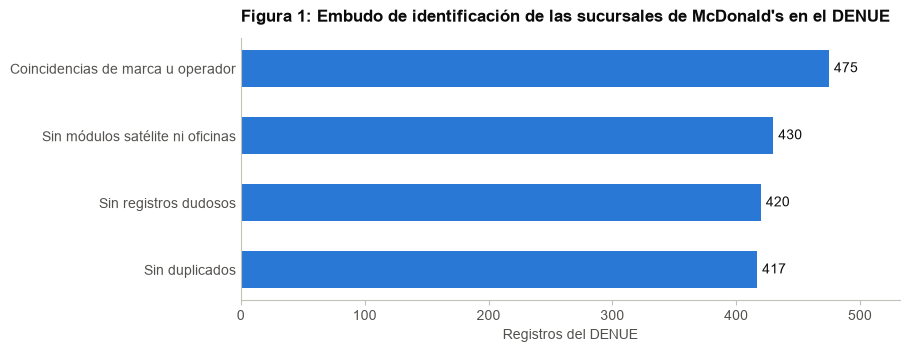

In [14]:
fig, ax = nueva_figura("Embudo de identificación de las sucursales de McDonald's en el DENUE", (8.5, 3.4))
y_pos = np.arange(len(embudo))[::-1]
ax.barh(y_pos, embudo.values, height=0.55, color=AZUL)
for yy, valor in zip(y_pos, embudo.values):
    ax.text(valor + 4, yy, f"{valor:,}", va="center", fontsize=10, color=TINTA)
ax.set_yticks(y_pos, embudo.index)
ax.set_xlabel("Registros del DENUE")
ax.set_xlim(0, embudo.max() * 1.12)
ax.tick_params(axis="y", length=0)
guardar(fig, "embudo_identificacion")

**Paso 5. Valores confidenciales del censo (completitud).** Para proteger la confidencialidad, el ITER oculta
con `*` los datos de las localidades con una o dos viviendas, y usa `N/D` cuando la información no está
disponible. Los totales municipales, en cambio, se publican completos.

In [15]:
VARS_CENSO = ["POBTOT", "P_12YMAS", "P_18A24", "GRAPROES", "PEA", "PDER_IMSS", "PDER_ISTE", "PDER_ISTEE",
              "TVIVPARHAB", "VPH_AUTOM", "VPH_INTER"]
tot_mun = iter_crudo[TOTALES_MUN].set_index("clave")
faltantes_censo = pd.DataFrame({
    "'*' en localidades": [(localidades[c] == "*").sum() for c in VARS_CENSO],
    "'N/D' en localidades": [(localidades[c] == "N/D").sum() for c in VARS_CENSO],
    "'*' o 'N/D' en totales municipales": [tot_mun[c].isin(["*", "N/D"]).sum() for c in VARS_CENSO],
}, index=VARS_CENSO)
display(faltantes_censo)
registrar("5. Valores confidenciales del censo", "Completitud", len(localidades),
          int((localidades.VPH_AUTOM == "*").sum()),
          "Se usan los totales municipales (completos); de las localidades sólo se usa POBTOT, que no tiene '*'")

,'*' en localidades,'N/D' en localidades,'*' o 'N/D' en totales municipales
POBTOT,0,0,0
P_12YMAS,81105,152,0
P_18A24,81105,152,0
GRAPROES,81105,152,0
PEA,81105,152,0
PDER_IMSS,81105,152,0
PDER_ISTE,81105,152,0
PDER_ISTEE,81105,152,0
TVIVPARHAB,81105,152,0
VPH_AUTOM,81105,152,0


**Paso 6. Agregación del DENUE a municipio (transformación).** Todo lo que coincidió con la marca o con un
operador (sucursales, módulos, duplicados y registros dudosos) se excluye antes de contar, para que ninguna
variable explicativa contenga a la variable objetivo, lo que sería fuga de información. Las 8 cadenas competidoras se identifican con patrones
de nombre acotados a la rama 7225. Se descartaron las marcas cuyos nombres generan falsos positivos genéricos
("POLLO ESTILO KENTUCKY", "TORTAS POPEYE", "TACOS WENDY S").

El personal ocupado sólo se publica en **estratos** (variable ordinal). Para estimar el empleo, cada estrato se
sustituye por su punto medio, y el estrato abierto "251 y más" por su límite inferior.

In [16]:
ids_mcdonalds = set(candidatos.id)
resto = denue[~denue.id.isin(ids_mcdonalds)]
rest = resto[resto.codigo_act.str.startswith("7225")].copy()
rest["empleo_estimado"] = rest.per_ocu.map(PUNTO_MEDIO)
rest["once_o_mas"] = ~rest.per_ocu.isin(["0 a 5 personas", "6 a 10 personas"])

CADENAS = {
    "Burger King": r"BURGER\s*KING",
    "KFC": r"\bKFC\b|KENTUCKY\s*FRIED",
    "Carl's Jr.": r"CARL'?\s?S\s*J(?:R|UNIOR)",
    "Domino's": r"DOMINO'?\s?S\b",
    "Little Caesars": r"LITTLE\s*CA?E?SAR",
    "Pizza Hut": r"PIZZA\s*HUT",
    "Starbucks": r"STAR\s*BUCKS",
    "Subway": r"\bSUBWAY\b",
}
texto_rest = (rest.nom_estab.fillna("") + " | " + rest.raz_social.fillna("")).str.upper()
rest["cadena"] = None
for cadena, patron in CADENAS.items():
    rest.loc[rest.cadena.isna() & texto_rest.str.contains(patron), "cadena"] = cadena
competencia = rest[rest.cadena.notna()]
resumen_cadenas = competencia.groupby("cadena").agg(sucursales=("id", "size"),
                                                   municipios=("clave_2020", "nunique"))
resumen_cadenas.loc["McDonald's (referencia)"] = [n_suc, n_mun]
display(resumen_cadenas.sort_values("sucursales", ascending=False))

plazas = resto[resto.tipoCenCom.eq("CENTRO Y PLAZA COMERCIAL") & resto.nom_CenCom.notna()].copy()
plazas["plaza"] = plazas.nom_CenCom.str.upper().str.replace(r"[^A-Z0-9]", "", regex=True)

g = rest.groupby("clave_2020")
establecimientos = pd.DataFrame({
    "restaurantes": g.size(),
    "restaurantes_11mas": g.once_o_mas.sum(),
    "empleo_restaurantes": g.empleo_estimado.sum(),
    "hoteles": resto[resto.codigo_act.str.startswith("7211")].groupby("clave_2020").size(),
    "plazas_comerciales": plazas.groupby("clave_2020").plaza.nunique(),
    "sucursales_competencia": competencia.groupby("clave_2020").size(),
    "marcas_competencia": competencia.groupby("clave_2020").cadena.nunique(),
    "sucursales_mcdonalds": sucursales.groupby("clave_2020").size(),
}).fillna(0)
establecimientos = establecimientos.astype({c: int for c in establecimientos.columns if c != "empleo_restaurantes"})
establecimientos.index.name = "clave_mun"
establecimientos.to_csv(PROCESADOS / "establecimientos_municipio.csv", encoding="utf-8-sig")
print(f"Municipios con al menos un establecimiento del sector 72: {len(establecimientos):,}")
registrar("6. Agregación del DENUE a municipio", "Consistencia", len(denue), len(ids_mcdonalds),
          "Se excluye todo registro de McDonald's de los conteos para evitar fuga de información")

,sucursales,municipios
cadena,,
Starbucks,935,141
Domino's,853,236
Little Caesars,707,201
Subway,612,163
KFC,516,146
McDonald's (referencia),417,123
Burger King,378,129
Carl's Jr.,371,107
Pizza Hut,121,77


Municipios con al menos un establecimiento del sector 72: 2,424


**Paso 7. Agregación del censo a municipio (transformación).** Los conteos se convierten en porcentajes para
que municipios de distinto tamaño sean comparables. Dos variables se calculan desde las localidades:

- la **urbanización**: la parte de la población que vive en localidades de 15,000 habitantes o más;
- la **localidad principal** (la más poblada), cuyas coordenadas ubican al municipio en el mapa.

In [17]:
v = tot_mun[VARS_CENSO].apply(pd.to_numeric)
censo = pd.DataFrame(index=tot_mun.index)
censo.index.name = "clave_mun"
censo["entidad"] = tot_mun.NOM_ENT
censo["municipio"] = tot_mun.NOM_MUN
censo["poblacion"] = v.POBTOT
censo["pct_jovenes"] = 100 * v.P_18A24 / v.POBTOT
censo["escolaridad"] = v.GRAPROES
censo["pct_viv_auto"] = 100 * v.VPH_AUTOM / v.TVIVPARHAB
censo["pct_viv_internet"] = 100 * v.VPH_INTER / v.TVIVPARHAB
censo["tasa_participacion"] = 100 * v.PEA / v.P_12YMAS
censo["pct_seguridad_social"] = 100 * (v.PDER_IMSS + v.PDER_ISTE + v.PDER_ISTEE) / v.POBTOT
urbana = localidades[localidades.pob >= 15_000].groupby("clave").pob.sum()
censo["pct_urbana"] = 100 * urbana.reindex(censo.index).fillna(0) / censo.poblacion
principal = localidades.sort_values("pob").groupby("clave").tail(1).set_index("clave")
censo["localidad_principal"] = principal.NOM_LOC
censo["latitud"] = principal.lat
censo["longitud"] = principal.lon
censo.to_csv(PROCESADOS / "censo2020_municipio.csv", encoding="utf-8-sig")
print(f"Municipios en el censo: {len(censo):,} · población total: {censo.poblacion.sum():,.0f}")
display(censo.head(3))

Municipios en el censo: 2,469 · población total: 126,014,024


,entidad,municipio,poblacion,pct_jovenes,escolaridad,pct_viv_auto,pct_viv_internet,tasa_participacion,pct_seguridad_social,pct_urbana,localidad_principal,latitud,longitud
clave_mun,,,,,,,,,,,,,
01001,Aguascalientes,Aguascalientes,948990,12.692652,10.84,63.608693,66.954172,64.292508,67.746446,91.032888,Aguascalientes,21.879823,-102.296047
01002,Aguascalientes,Asientos,51536,12.769714,8.54,52.934141,36.086749,55.834787,38.932009,0.000000,Villa Juárez,22.095563,-102.070792
01003,Aguascalientes,Calvillo,58250,11.905579,8.05,58.098546,42.152322,58.010630,23.095279,36.135622,Calvillo,21.846907,-102.718751


**Paso 8. Integración, tasas y carga.** El censo es la tabla base, porque define el universo de 2,469
municipios. Los conteos del DENUE se unen por la clave municipal y se convierten en tasas por habitante.
Un municipio sin ningún establecimiento del sector 72 recibe **cero**, no un faltante: el DENUE es un censo de
establecimientos, así que su ausencia es un dato verdadero. Al final se validan las reglas de integridad y se
escribe la tabla analítica.

In [18]:
tabla = censo.join(establecimientos, how="left")
conteos = list(establecimientos.columns)
sin_sector_72 = int(tabla.restaurantes.isna().sum())
tabla[conteos] = tabla[conteos].fillna(0)
tabla["restaurantes_10k"] = 1e4 * tabla.restaurantes / tabla.poblacion
tabla["pct_rest_11mas"] = np.where(tabla.restaurantes > 0, 100 * tabla.restaurantes_11mas / tabla.restaurantes, 0)
tabla["hoteles_10k"] = 1e4 * tabla.hoteles / tabla.poblacion
tabla["empleo_restaurantes_1k"] = 1e3 * tabla.empleo_restaurantes / tabla.poblacion
for c in ["plazas_comerciales", "sucursales_competencia", "marcas_competencia", "sucursales_mcdonalds"]:
    tabla[c] = tabla[c].astype(int)
tabla["tiene_mcdonalds"] = (tabla.sucursales_mcdonalds > 0).astype(int)
registrar("7. Municipios sin establecimientos del sector 72", "Completitud", len(tabla), sin_sector_72,
          "Se imputa 0: la ausencia en el DENUE es un dato, no un faltante")

# ---- Validaciones de integridad ------------------------------------------------------------
assert len(tabla) == 2469, "Deben quedar los 2,469 municipios del censo"
assert tabla[X_COLS].notna().all().all(), "La tabla del modelo no admite faltantes"
assert np.isfinite(tabla[X_COLS].to_numpy()).all(), "Hay divisiones entre cero"
assert tabla.sucursales_mcdonalds.sum() == n_suc, "Se perdieron sucursales en la unión"
assert tabla[["pct_urbana", "pct_viv_auto", "pct_viv_internet", "pct_rest_11mas"]].le(100).all().all()

COLS_SALIDA = ["entidad", "municipio", "localidad_principal", "latitud", "longitud"] + X_COLS + [
    "sucursales_mcdonalds", "tiene_mcdonalds"]
tabla[COLS_SALIDA].to_csv(ANALITICOS / "tabla_modelo.csv", encoding="utf-8-sig")
registrar("8. Carga de la tabla analítica", "Integridad", len(tabla), 0,
          "Validaciones superadas; se escribe datos/analiticos/tabla_modelo.csv")
print(f"Tabla analítica: {tabla[COLS_SALIDA].shape[0]:,} municipios × {tabla[COLS_SALIDA].shape[1] + 1} columnas "
      f"(incluida la clave) · con McDonald's: {tabla.tiene_mcdonalds.sum()} "
      f"({100 * tabla.tiene_mcdonalds.mean():.1f} %)")

Tabla analítica: 2,469 municipios × 23 columnas (incluida la clave) · con McDonald's: 123 (5.0 %)


**Paso 9. Transformación de distribuciones y tratamiento de atípicos.** Los conteos y las tasas por habitante
tienen asimetría positiva extrema: pocos municipios muy grandes o muy turísticos y miles de municipios
pequeños. Ante los valores atípicos hay tres opciones:

1. **Eliminar.** Se descarta: los municipios extremos (las alcaldías de la Ciudad de México, Monterrey,
   Cancún) son legítimos y son justo donde está la marca.
2. **Transformar.** `log1p` vuelve casi simétricas las variables sesgadas y admite ceros. Se aplica dentro del
   modelo Naive Bayes, que supone distribuciones normales.
3. **Métodos robustos.** Se usan en el análisis y en el modelo:
   - medianas y pruebas de rangos en el análisis descriptivo;
   - árboles de decisión y random forest, que no cambian ante transformaciones monótonas, en el modelo.

   Por eso la tabla analítica conserva las variables en su escala original: las reglas del árbol se leen
   directamente en habitantes, porcentajes y sucursales.

Por la misma razón no hace falta normalizar con min-max ni estandarizar para los árboles: el corte de un nodo
depende del orden de los valores, no de su escala.

In [19]:
asimetria = pd.DataFrame({"asimetría original": tabla[X_COLS].skew(),
                          "asimetría con log1p": np.log1p(tabla[X_COLS]).skew()})
asimetria["bloque"] = asimetria.index.map(BLOQUE_DE)
SESGADAS = asimetria.index[asimetria["asimetría original"] > 2].tolist()
display(asimetria.round(2))
print(f"Variables con asimetría > 2: {len(SESGADAS)} de {len(X_COLS)}")
registrar("9. Asimetría y valores atípicos", "Exactitud", len(tabla), 0,
          "No se eliminan atípicos; log1p dentro de Naive Bayes y modelos robustos (árboles)")

print("\nBitácora de limpieza y transformación")
display(pd.DataFrame(bitacora))

,asimetría original,asimetría con log1p,bloque
poblacion,6.89,0.14,Demanda
pct_urbana,1.68,1.31,Demanda
pct_jovenes,-0.58,-1.55,Demanda
escolaridad,0.33,-0.20,Poder adquisitivo
pct_viv_auto,0.33,-0.91,Poder adquisitivo
pct_viv_internet,0.69,-0.87,Poder adquisitivo
tasa_participacion,-0.85,-1.56,Empleo
pct_seguridad_social,0.97,-0.39,Empleo
empleo_restaurantes_1k,2.47,-0.94,Empleo
restaurantes_10k,2.60,-1.64,Sector y turismo


Variables con asimetría > 2: 8 de 15

Bitácora de limpieza y transformación


,paso,dimensión de calidad,registros revisados,registros afectados,decisión
0,1. id repetido en el DENUE,Duplicación,806496,1,Se elimina la copia; ambas filas son idénticas
1,2a. Coordenadas del DENUE,Exactitud,806495,0,Todas dentro del territorio; no se elimina nada
2,2b. Coordenadas del ITER en grados-minutos-segundos,Conformidad,189432,189432,Se convierten a grados decimales
3,3. Municipios creados después de 2020,Integridad,806495,1796,Los establecimientos de 8 municipios nuevos se asignan a su munici...
4,4. Identificación de McDonald's,Conformidad y consistencia,806495,417,417 sucursales en 123 municipios
5,5. Valores confidenciales del censo,Completitud,189432,81105,Se usan los totales municipales (completos); de las localidades só...
6,6. Agregación del DENUE a municipio,Consistencia,806495,475,Se excluye todo registro de McDonald's de los conteos para evitar ...
7,7. Municipios sin establecimientos del sector 72,Completitud,2469,45,"Se imputa 0: la ausencia en el DENUE es un dato, no un faltante"
8,8. Carga de la tabla analítica,Integridad,2469,0,Validaciones superadas; se escribe datos/analiticos/tabla_modelo.csv
9,9. Asimetría y valores atípicos,Exactitud,2469,0,No se eliminan atípicos; log1p dentro de Naive Bayes y modelos rob...


### 2.4 Análisis de datos (estadística descriptiva)

**Métricas de las 15 variables explicativas.** Se reportan media, mediana, desviación estándar, mínimo,
máximo, rango intercuartílico (IQR) y asimetría.

In [20]:
metricas = pd.DataFrame({
    "media": tabla[X_COLS].mean(), "mediana": tabla[X_COLS].median(), "desv. est.": tabla[X_COLS].std(),
    "mínimo": tabla[X_COLS].min(), "máximo": tabla[X_COLS].max(),
    "IQR": tabla[X_COLS].quantile(0.75) - tabla[X_COLS].quantile(0.25), "asimetría": tabla[X_COLS].skew(),
})
metricas.insert(0, "bloque", metricas.index.map(BLOQUE_DE))
display(metricas.round(2))

,bloque,media,mediana,desv. est.,mínimo,máximo,IQR,asimetría
poblacion,Demanda,51038.49,13552.00,146990.73,81.00,1922523.00,30795.00,6.89
pct_urbana,Demanda,15.37,0.00,30.05,0.00,100.00,0.00,1.68
pct_jovenes,Demanda,10.82,11.04,1.69,1.26,20.22,2.10,-0.58
escolaridad,Poder adquisitivo,7.83,7.71,1.49,3.40,14.55,1.93,0.33
pct_viv_auto,Poder adquisitivo,34.25,32.52,19.45,1.11,91.93,30.43,0.33
pct_viv_internet,Poder adquisitivo,27.09,24.11,17.75,0.00,91.90,25.43,0.69
tasa_participacion,Empleo,54.45,56.48,9.42,14.01,77.60,12.76,-0.85
pct_seguridad_social,Empleo,21.97,16.26,18.31,0.00,84.58,25.17,0.97
empleo_restaurantes_1k,Empleo,19.14,16.66,14.42,0.00,193.73,16.58,2.47
restaurantes_10k,Sector y turismo,55.38,49.52,39.44,0.00,626.78,44.94,2.60


Entidades sin ninguna sucursal: []


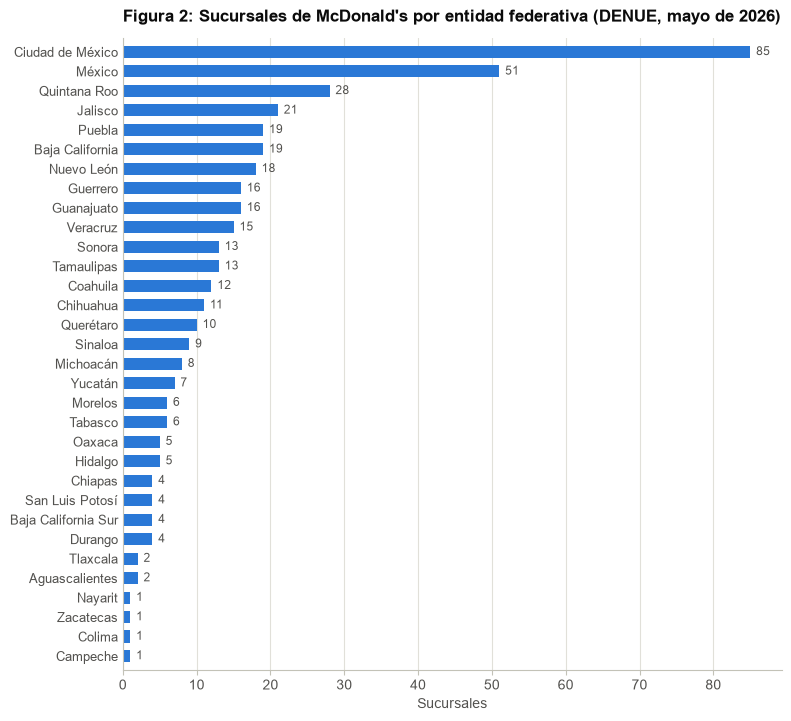

,sucursales,municipios,poblacion,sucursales por millón de hab.
entidad,,,,
Ciudad de México,85,14,9209944,9.2
México,51,20,16992418,3.0
Quintana Roo,28,3,1857985,15.1
Jalisco,21,4,8348151,2.5
Baja California,19,5,3769020,5.0
Puebla,19,5,6583278,2.9
Nuevo León,18,7,5784442,3.1
Guanajuato,16,6,6166934,2.6


In [21]:
CORTOS = {"Veracruz de Ignacio de la Llave": "Veracruz", "Coahuila de Zaragoza": "Coahuila",
          "Michoacán de Ocampo": "Michoacán"}
por_entidad = (tabla.groupby("entidad")
               .agg(sucursales=("sucursales_mcdonalds", "sum"), municipios=("tiene_mcdonalds", "sum"),
                    poblacion=("poblacion", "sum")))
por_entidad["sucursales por millón de hab."] = 1e6 * por_entidad.sucursales / por_entidad.poblacion
por_entidad = por_entidad.sort_values("sucursales")
print(f"Entidades sin ninguna sucursal: {por_entidad.index[por_entidad.sucursales == 0].tolist()}")

fig, ax = nueva_figura("Sucursales de McDonald's por entidad federativa (DENUE, mayo de 2026)", (8.5, 8.2))
etiquetas = [CORTOS.get(e, e) for e in por_entidad.index]
ax.barh(etiquetas, por_entidad.sucursales, height=0.62, color=AZUL)
for i, valor in enumerate(por_entidad.sucursales):
    ax.text(valor + 0.8, i, f"{valor:,}", va="center", fontsize=8.5, color=TINTA_2)
ax.set_xlabel("Sucursales")
ax.set_ylim(-0.7, len(por_entidad) - 0.3)
ax.tick_params(axis="y", length=0, labelsize=9)
ax.grid(axis="x")
ax.set_axisbelow(True)
guardar(fig, "sucursales_por_entidad")
display(por_entidad.sort_values("sucursales", ascending=False).head(8).round(1))

**Comparación entre municipios con y sin McDonald's (análisis diagnóstico).** Las variables son asimétricas,
así que la comparación usa medianas y la prueba no paramétrica **U de Mann-Whitney** en lugar de la prueba t.
El tamaño del efecto es la **correlación biserial de rangos**:

- r = +1: todo municipio con McDonald's supera a todo municipio sin McDonald's en esa variable;
- r = 0: no hay diferencia;
- r = −1: la relación es la inversa.

In [22]:
con = tabla[tabla.tiene_mcdonalds == 1]
sin = tabla[tabla.tiene_mcdonalds == 0]
filas = []
for v_ in X_COLS:
    u, p = stats.mannwhitneyu(con[v_], sin[v_], alternative="two-sided")
    filas.append({"variable": v_, "bloque": BLOQUE_DE[v_],
                  "mediana con McDonald's": con[v_].median(), "mediana sin McDonald's": sin[v_].median(),
                  "U": u, "valor p": p, "efecto r": 2 * u / (len(con) * len(sin)) - 1})
comparacion = pd.DataFrame(filas).set_index("variable").sort_values("efecto r", ascending=False)
significativas = int((comparacion["valor p"] < 0.05).sum())
vista = comparacion.copy()
vista["valor p"] = vista["valor p"].map(lambda p: f"{p:.1e}")
display(vista.round(3))
print(f"Municipios con McDonald's: {len(con)} · sin McDonald's: {len(sin):,}")
print(f"Variables con diferencia significativa (p < 0.05): {significativas} de {len(X_COLS)}")

,bloque,mediana con McDonald's,mediana sin McDonald's,U,valor p,efecto r
variable,,,,,,
sucursales_competencia,Competencia,20.000,0.000,285630.5,3.5e-222,0.980
marcas_competencia,Competencia,7.000,0.000,285506.0,8.2e-222,0.979
plazas_comerciales,Sector y turismo,25.000,0.000,284177.5,1.7e-148,0.970
poblacion,Demanda,378476.000,12364.500,284011.0,1.8e-73,0.968
pct_viv_internet,Poder adquisitivo,64.773,23.082,280067.0,1.8e-69,0.941
escolaridad,Poder adquisitivo,10.700,7.620,279079.5,1.7e-68,0.934
pct_urbana,Demanda,91.277,0.000,277462.5,2.1e-120,0.923
pct_rest_11mas,Sector y turismo,4.598,0.000,274639.5,1.2e-87,0.904
pct_seguridad_social,Empleo,56.035,15.299,267165.0,3.1e-57,0.852


Municipios con McDonald's: 123 · sin McDonald's: 2,346
Variables con diferencia significativa (p < 0.05): 15 de 15


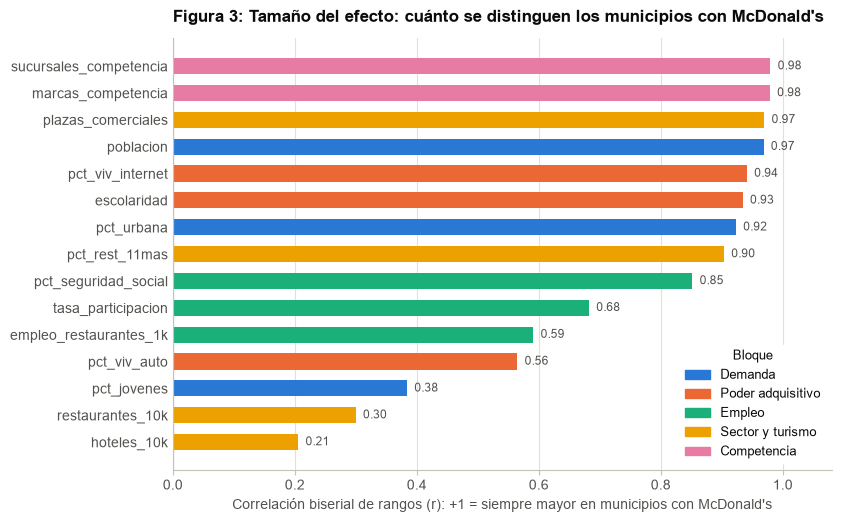

In [23]:
orden = comparacion.sort_values("efecto r")
fig, ax = nueva_figura("Tamaño del efecto: cuánto se distinguen los municipios con McDonald's", (8.5, 5.6))
colores = [COLOR_BLOQUE[BLOQUE_DE[v_]] for v_ in orden.index]
ax.barh(orden.index, orden["efecto r"], height=0.6, color=colores)
for i, r in enumerate(orden["efecto r"]):
    ax.text(r + 0.012 if r >= 0 else r - 0.012, i, f"{r:.2f}", va="center",
            ha="left" if r >= 0 else "right", fontsize=8.5, color=TINTA_2)
ax.axvline(0, color=GRIS, linewidth=0.8)
ax.set_xlim(min(0, orden["efecto r"].min() - 0.1), 1.08)
ax.set_xlabel("Correlación biserial de rangos (r): +1 = siempre mayor en municipios con McDonald's")
ax.tick_params(axis="y", length=0)
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.legend(handles=[Patch(color=c, label=b) for b, c in COLOR_BLOQUE.items()], loc="lower right", fontsize=9,
          title="Bloque", title_fontsize=9, framealpha=1, frameon=True, edgecolor=FONDO)
guardar(fig, "tamano_efecto")

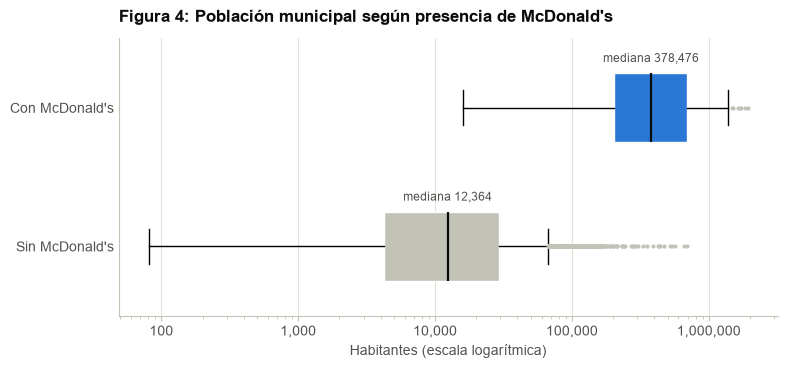

In [24]:
fig, ax = nueva_figura("Población municipal según presencia de McDonald's", (8.5, 3.6))
bp = ax.boxplot([sin.poblacion, con.poblacion], orientation="horizontal", widths=0.5, patch_artist=True,
                tick_labels=["Sin McDonald's", "Con McDonald's"], showfliers=True,
                flierprops={"marker": "o", "markersize": 3, "markerfacecolor": GRIS, "markeredgecolor": "none"},
                medianprops={"color": TINTA, "linewidth": 1.6})
for caja, color in zip(bp["boxes"], [GRIS, AZUL]):
    caja.set_facecolor(color)
    caja.set_edgecolor(FONDO)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlabel("Habitantes (escala logarítmica)")
ax.tick_params(axis="y", length=0)
ax.grid(axis="x")
ax.set_axisbelow(True)
for i, grupo in enumerate([sin, con], start=1):
    ax.text(grupo.poblacion.median(), i + 0.33, f"mediana {grupo.poblacion.median():,.0f}", ha="center",
            fontsize=8.5, color=TINTA_2)
guardar(fig, "poblacion_por_grupo")

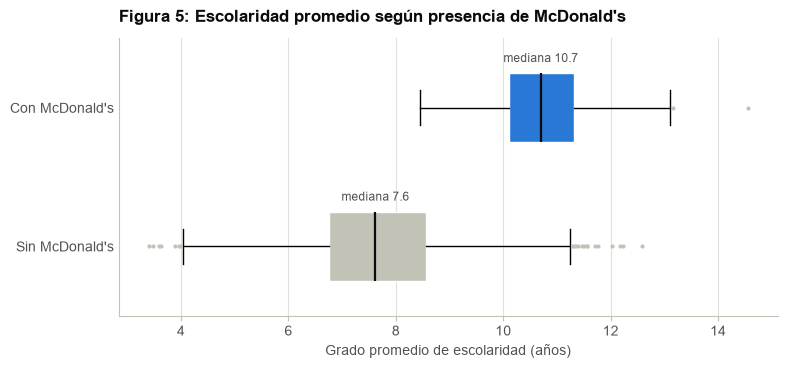

In [25]:
fig, ax = nueva_figura("Escolaridad promedio según presencia de McDonald's", (8.5, 3.6))
bp = ax.boxplot([sin.escolaridad, con.escolaridad], orientation="horizontal", widths=0.5, patch_artist=True,
                tick_labels=["Sin McDonald's", "Con McDonald's"], showfliers=True,
                flierprops={"marker": "o", "markersize": 3, "markerfacecolor": GRIS, "markeredgecolor": "none"},
                medianprops={"color": TINTA, "linewidth": 1.6})
for caja, color in zip(bp["boxes"], [GRIS, AZUL]):
    caja.set_facecolor(color)
    caja.set_edgecolor(FONDO)
ax.set_xlabel("Grado promedio de escolaridad (años)")
ax.tick_params(axis="y", length=0)
ax.grid(axis="x")
ax.set_axisbelow(True)
for i, grupo in enumerate([sin, con], start=1):
    ax.text(grupo.escolaridad.median(), i + 0.33, f"mediana {grupo.escolaridad.median():.1f}", ha="center",
            fontsize=8.5, color=TINTA_2)
guardar(fig, "escolaridad_por_grupo")

**Matriz de correlación.** Se usa la correlación de **Spearman** (de rangos), más adecuada que la de Pearson
ante la asimetría y los valores atípicos. Sirve para dos cosas:

- ver qué variables acompañan a `tiene_mcdonalds`;
- detectar **multicolinealidad**, es decir, variables que miden casi lo mismo.

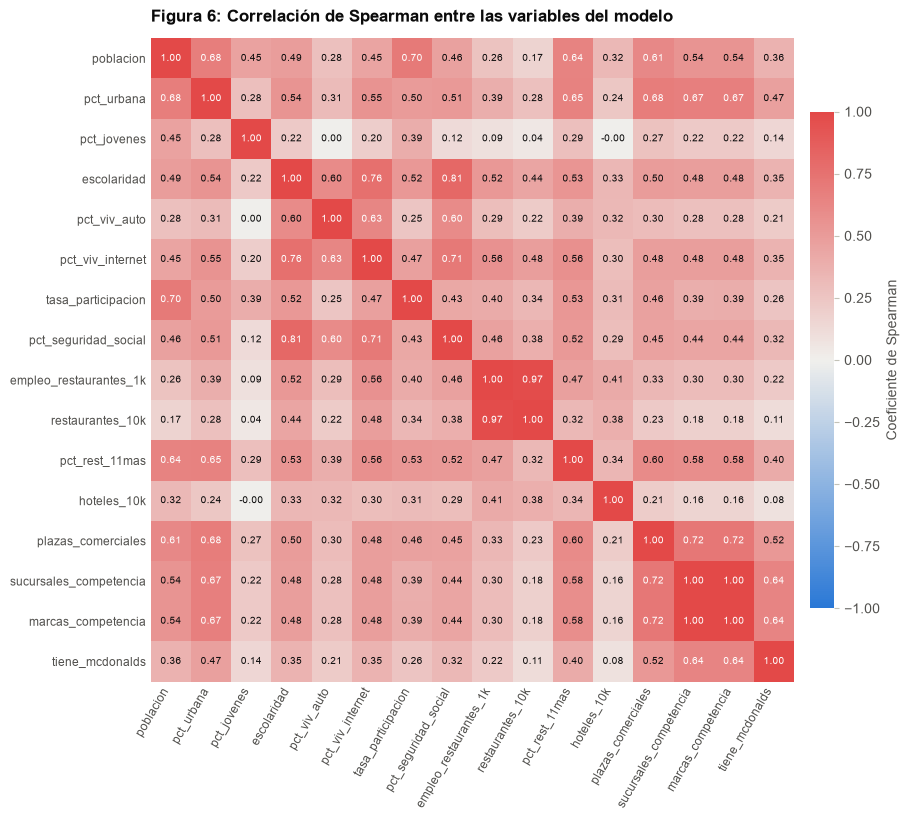

Pares de variables explicativas más correlacionados:


,level_0,level_1,rho
209,sucursales_competencia,marcas_competencia,1.000
129,empleo_restaurantes_1k,restaurantes_10k,0.975
52,escolaridad,pct_seguridad_social,0.809
50,escolaridad,pct_viv_internet,0.761
193,plazas_comerciales,sucursales_competencia,0.718
194,plazas_comerciales,marcas_competencia,0.718


Correlación de cada variable con tiene_mcdonalds:


,tiene_mcdonalds
sucursales_competencia,0.641
marcas_competencia,0.640
plazas_comerciales,0.522
pct_urbana,0.470
pct_rest_11mas,0.400
poblacion,0.365
pct_viv_internet,0.355
escolaridad,0.352
pct_seguridad_social,0.321
tasa_participacion,0.257


In [26]:
corr = tabla[X_COLS + ["tiene_mcdonalds"]].corr(method="spearman")
fig, ax = nueva_figura("Correlación de Spearman entre las variables del modelo", (10, 8.6))
im = ax.imshow(corr.values, cmap=CMAP_DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=60, ha="right", fontsize=8.5)
ax.set_yticks(range(len(corr)), corr.index, fontsize=8.5)
for i in range(len(corr)):
    for j in range(len(corr)):
        valor = corr.values[i, j]
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=7,
                color=FONDO if abs(valor) > 0.6 else TINTA)
ax.tick_params(length=0)
for lado in ax.spines.values():
    lado.set_visible(False)
barra = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
barra.set_label("Coeficiente de Spearman")
barra.outline.set_visible(False)
guardar(fig, "matriz_correlacion")

pares = (corr.loc[X_COLS, X_COLS].where(np.triu(np.ones((len(X_COLS),) * 2, dtype=bool), 1))
         .stack().rename("rho").reset_index())
pares = pares.reindex(pares.rho.abs().sort_values(ascending=False).index).head(6)
print("Pares de variables explicativas más correlacionados:")
display(pares.round(3))
print("Correlación de cada variable con tiene_mcdonalds:")
display(corr["tiene_mcdonalds"].drop("tiene_mcdonalds").sort_values(ascending=False).round(3).to_frame())

### Conclusiones del entendimiento de los datos

1. **Calidad de los datos.** Las fuentes son de buena calidad, pero no están listas para unirse.
   - El DENUE trae un registro duplicado, justo en el corte entre sus dos archivos.
   - Ocho municipios creados después de 2020 suman 1,796 establecimientos sin contraparte en el censo.
   - La marca no tiene un campo propio: aparece escrita de 14 formas distintas, mezclada con módulos de postres,
     oficinas y negocios ajenos, y en Michoacán se registra sin el nombre.
   - Tras la limpieza quedan **417 sucursales en 123 municipios** (5.0 % de los municipios). La cifra es
     consistente con las más de 380 que reporta la operadora.
2. **McDonald's es un negocio de ciudades grandes.** La mediana de población de los municipios con sucursal
   es de 378 mil habitantes, contra 12 mil de los demás. Un tercio de las sucursales está en la Ciudad de
   México y el Estado de México.
3. **Todos los factores de la hipótesis separan a los dos grupos.** Las 15 variables tienen diferencias
   significativas (p < 0.05). Los efectos más grandes (r > 0.9) son:
   - la competencia: mediana de 7 cadenas rivales contra 0;
   - las plazas comerciales;
   - la población;
   - el internet en la vivienda: 64.8 % contra 23.1 %;
   - la escolaridad: 10.7 años contra 7.6;
   - la urbanización.

   El turismo (`hoteles_10k`) y la densidad de restaurantes (`restaurantes_10k`) separan poco: por habitante,
   los pueblos pequeños también tienen muchas fondas y hoteles.
4. **El empleo acompaña a la marca.** La afiliación al IMSS o al ISSSTE es de 56 % en los municipios con
   sucursal y de 15 % en los demás. Las 417 sucursales emplean, según los estratos del DENUE, a unas 14,400
   personas; el 95 % de ellas tiene de 11 a 100 empleados.
5. **Hay multicolinealidad.** Tres pares de variables miden casi lo mismo:
   - sucursales y marcas de la competencia (ρ = 1.00);
   - empleo y densidad de restaurantes (ρ = 0.97);
   - escolaridad y seguridad social (ρ = 0.81).

   No afecta a los árboles, pero viola el supuesto de independencia de Naive Bayes y obliga a interpretar las
   importancias por bloque, no sólo por variable.
6. **Asimetría.** 8 de las 15 variables tienen asimetría mayor que 2. Por eso se usan medianas, pruebas de
   rangos, correlación de Spearman y modelos basados en árboles.

---
## 3. Modelado analítico

### 3.1 Algoritmo a aplicar

El problema es de **aprendizaje supervisado**: cada municipio tiene una etiqueta conocida (`tiene_mcdonalds`)
y se busca una función que la prediga a partir de las 15 variables. Es una **clasificación binaria**. No es una
regresión, porque la pregunta es "¿hay mercado?" y no "¿cuántas sucursales?". Tampoco es un agrupamiento, porque
la etiqueta existe y hay que aprovecharla.

Se comparan tres algoritmos:

| Algoritmo | Cómo decide | Por qué se incluye |
|---|---|---|
| **Árbol de decisión** | Parte los datos con cortes sucesivos sobre una variable a la vez, eligiendo el corte que más reduce la impureza (Gini o entropía) | Produce **reglas legibles** ("si la población > X y hay más de Y cadenas rivales..."), útiles para explicar la decisión al negocio |
| **Naive Bayes gaussiano** | Aplica el teorema de Bayes suponiendo que las variables son independientes dentro de cada clase y normales (tras `log1p`) | **Línea base** probabilística, rápida y sin casi parámetros |
| **Random forest** | Promedia cientos de árboles, cada uno entrenado con una muestra *bootstrap* y un subconjunto aleatorio de variables en cada corte | Reduce la varianza de un árbol único, tolera la colinealidad y los atípicos, y da una **probabilidad continua**, útil para ordenar candidatos |

**Regla de elección.** Los modelos cumplen dos papeles distintos:

- **Modelo de puntuación.** Es el que califica y ordena a los municipios: el de mayor AUC en validación
  cruzada sobre el conjunto de entrenamiento. El conjunto de prueba sólo confirma su desempeño; nunca se usa
  para elegirlo.
- **Modelo explicativo.** Es siempre el árbol de decisión, aunque no gane, porque traduce el perfil en
  reglas que el negocio puede leer.

Un árbol único con pocas hojas da probabilidades gruesas: muchos municipios comparten la misma hoja y quedan
empatados. Eso lo vuelve débil para ordenar candidatos, aunque su AUC sea parecido al de los otros modelos.

**Métrica principal: AUC ROC.** La clase positiva es pequeña (alrededor del 5 % de los municipios), por lo que la
exactitud engaña: un modelo que dijera "no" siempre acertaría más del 95 %. El área bajo la curva ROC mide qué
tan bien ordena el modelo a los municipios: es la probabilidad de que un municipio con McDonald's elegido al
azar reciba una calificación mayor que uno sin McDonald's. Como complemento se reportan la precisión promedio
(área bajo la curva precisión-exhaustividad) y la matriz de confusión.

### 3.2 Parámetros de configuración

Los hiperparámetros se eligen con **búsqueda en rejilla** (`GridSearchCV`):

- validación cruzada **estratificada de 5 pliegues**, que conserva la proporción de positivos en cada pliegue;
- AUC como criterio;
- se usa **sólo el conjunto de entrenamiento**.

Para compensar el desbalance, el árbol puede ponderar las clases (`class_weight="balanced"`) y el random
forest lo hace en cada muestra *bootstrap* (`balanced_subsample`). La semilla es 42 en todos los procesos
aleatorios.

In [27]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
MODELOS = {
    "Árbol de decisión": (
        DecisionTreeClassifier(random_state=SEMILLA),
        {"max_depth": [2, 3, 4, 5, 6], "min_samples_leaf": [5, 10, 20, 40],
         "criterion": ["gini", "entropy"], "class_weight": [None, "balanced"]}),
    "Naive Bayes": (
        Pipeline([("log1p", FunctionTransformer(np.log1p)), ("nb", GaussianNB())]),
        {"nb__var_smoothing": np.logspace(-12, -2, 11)}),
    "Random forest": (
        RandomForestClassifier(n_estimators=400, class_weight="balanced_subsample", random_state=SEMILLA, n_jobs=1),
        {"max_depth": [4, 6, 8, None], "min_samples_leaf": [1, 3, 5, 10], "max_features": ["sqrt", 0.5]}),
}
DESCRIPCION = {
    "max_depth": "profundidad máxima del árbol", "min_samples_leaf": "mínimo de municipios por hoja",
    "criterion": "medida de impureza", "class_weight": "ponderación de clases",
    "nb__var_smoothing": "suavizado de varianzas", "max_features": "fracción de variables por corte",
}
rejilla = pd.DataFrame([{"modelo": m, "parámetro": p, "significado": DESCRIPCION[p],
                         "valores probados": ", ".join(f"{x:.0e}" if isinstance(x, float) and x < 1e-2 else str(x)
                                                       for x in vals)}
                        for m, (_, params) in MODELOS.items() for p, vals in params.items()])
display(rejilla)
print("Fijos: random forest con 400 árboles y class_weight='balanced_subsample'; Naive Bayes con log1p previo.")

,modelo,parámetro,significado,valores probados
0,Árbol de decisión,max_depth,profundidad máxima del árbol,"2, 3, 4, 5, 6"
1,Árbol de decisión,min_samples_leaf,mínimo de municipios por hoja,"5, 10, 20, 40"
2,Árbol de decisión,criterion,medida de impureza,"gini, entropy"
3,Árbol de decisión,class_weight,ponderación de clases,"None, balanced"
4,Naive Bayes,nb__var_smoothing,suavizado de varianzas,"1e-12, 1e-11, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 1e-04, 1e-..."
5,Random forest,max_depth,profundidad máxima del árbol,"4, 6, 8, None"
6,Random forest,min_samples_leaf,mínimo de municipios por hoja,"1, 3, 5, 10"
7,Random forest,max_features,fracción de variables por corte,"sqrt, 0.5"


Fijos: random forest con 400 árboles y class_weight='balanced_subsample'; Naive Bayes con log1p previo.


### 3.3 Datos de entrenamiento

La tabla se divide **70 % entrenamiento y 30 % prueba**, estratificando por la variable objetivo para que ambas
partes tengan la misma proporción de municipios con McDonald's. Con el conjunto de entrenamiento se ajustan las
tres búsquedas en rejilla.

In [28]:
X = tabla[X_COLS]
y = tabla.tiene_mcdonalds
X_ent, X_pru, y_ent, y_pru = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEMILLA)
particion = pd.DataFrame({"municipios": [len(y_ent), len(y_pru)],
                          "con McDonald's": [int(y_ent.sum()), int(y_pru.sum())]},
                         index=["Entrenamiento (70 %)", "Prueba (30 %)"])
particion["% con McDonald's"] = (100 * particion["con McDonald's"] / particion.municipios).round(2)
display(particion)

busquedas = {}
for nombre_modelo, (modelo, parametros) in MODELOS.items():
    busqueda = GridSearchCV(modelo, parametros, scoring="roc_auc", cv=CV, n_jobs=-1, refit=True)
    busqueda.fit(X_ent, y_ent)
    busquedas[nombre_modelo] = busqueda

resumen_cv = pd.DataFrame({
    n: {"combinaciones": len(b.cv_results_["params"]),
        "AUC VC (media)": b.best_score_,
        "AUC VC (desv. est.)": b.cv_results_["std_test_score"][b.best_index_],
        "mejores parámetros": b.best_params_}
    for n, b in busquedas.items()}).T
display(resumen_cv)

auc_cv = resumen_cv["AUC VC (media)"].astype(float)
ELEGIDO = auc_cv.idxmax()
print(f"Modelo de puntuación (mayor AUC en validación cruzada): {ELEGIDO} ({auc_cv[ELEGIDO]:.3f})")
print("Modelo explicativo: Árbol de decisión "
      f"({auc_cv['Árbol de decisión']:.3f}, {auc_cv[ELEGIDO] - auc_cv['Árbol de decisión']:.3f} por debajo)")

,municipios,con McDonald's,% con McDonald's
Entrenamiento (70 %),1728,86,4.98
Prueba (30 %),741,37,4.99


,combinaciones,AUC VC (media),AUC VC (desv. est.),mejores parámetros
Árbol de decisión,80,0.98271,0.01648,"{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, ..."
Naive Bayes,11,0.993035,0.002688,{'nb__var_smoothing': 0.01}
Random forest,32,0.995897,0.002875,"{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 10}"


Modelo de puntuación (mayor AUC en validación cruzada): Random forest (0.996)
Modelo explicativo: Árbol de decisión (0.983, 0.013 por debajo)


### 3.4 Datos de prueba

El 30 % reservado nunca participó en el ajuste ni en la elección de parámetros. Sobre él se calcula el
desempeño de los tres modelos. Las métricas que dependen de un umbral usan 0.5: un municipio se clasifica
"con McDonald's" si su probabilidad es de 0.5 o más.

In [29]:
prob_prueba, filas = {}, []
for nombre_modelo, busqueda in busquedas.items():
    p = busqueda.predict_proba(X_pru)[:, 1]
    prob_prueba[nombre_modelo] = p
    pred = (p >= 0.5).astype(int)
    filas.append({"modelo": nombre_modelo,
                  "AUC ROC": roc_auc_score(y_pru, p),
                  "precisión promedio": average_precision_score(y_pru, p),
                  "exactitud": accuracy_score(y_pru, pred),
                  "exactitud balanceada": balanced_accuracy_score(y_pru, pred),
                  "precisión": precision_score(y_pru, pred, zero_division=0),
                  "exhaustividad": recall_score(y_pru, pred),
                  "F1": f1_score(y_pru, pred)})
desempeno = pd.DataFrame(filas).set_index("modelo")
display(desempeno.round(3))
print(f"Proporción de positivos en prueba (precisión promedio de un modelo al azar): {y_pru.mean():.3f}")

,AUC ROC,precisión promedio,exactitud,exactitud balanceada,precisión,exhaustividad,F1
modelo,,,,,,,
Árbol de decisión,0.924,0.719,0.965,0.918,0.604,0.865,0.711
Naive Bayes,0.986,0.826,0.964,0.930,0.589,0.892,0.710
Random forest,0.988,0.840,0.974,0.910,0.705,0.838,0.765


Proporción de positivos en prueba (precisión promedio de un modelo al azar): 0.050


### 3.5 Resultados del modelo y evaluación

**Curva ROC.** Muestra, para todos los umbrales posibles, la tasa de verdaderos positivos (exhaustividad)
contra la tasa de falsos positivos. La diagonal es un modelo al azar (AUC = 0.5). Cuanto más se acerca la
curva a la esquina superior izquierda, mejor ordena el modelo.

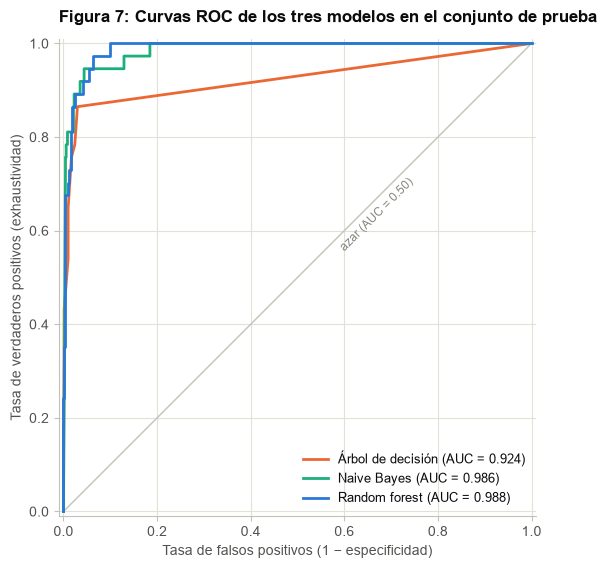

In [30]:
COLOR_MODELO = {"Árbol de decisión": NARANJA, "Naive Bayes": AQUA, "Random forest": AZUL}
fig, ax = nueva_figura("Curvas ROC de los tres modelos en el conjunto de prueba", (6.8, 6.2))
ax.plot([0, 1], [0, 1], color=GRIS, linewidth=1)
ax.text(0.60, 0.555, "azar (AUC = 0.50)", color=TENUE, fontsize=8.5, rotation=45, rotation_mode="anchor")
for nombre_modelo, p in prob_prueba.items():
    fpr, tpr, _ = roc_curve(y_pru, p)
    ax.plot(fpr, tpr, color=COLOR_MODELO[nombre_modelo], linewidth=2,
            label=f"{nombre_modelo} (AUC = {roc_auc_score(y_pru, p):.3f})")
ax.set_xlabel("Tasa de falsos positivos (1 − especificidad)")
ax.set_ylabel("Tasa de verdaderos positivos (exhaustividad)")
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.set_aspect("equal")
ax.grid(True)
ax.set_axisbelow(True)
ax.legend(loc="lower right", fontsize=9)
guardar(fig, "curvas_roc")

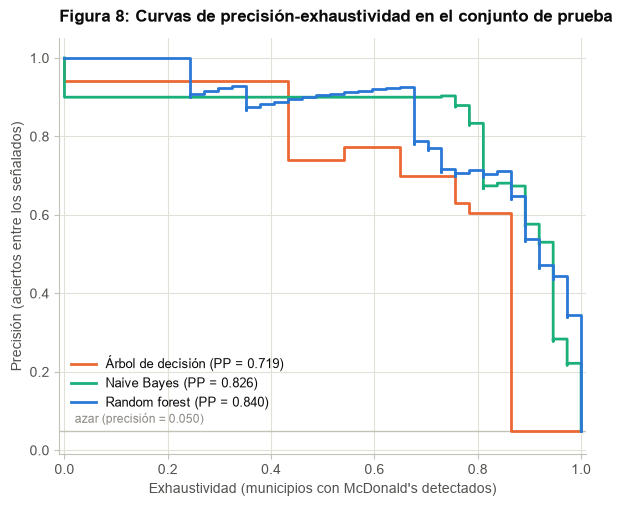

In [31]:
fig, ax = nueva_figura("Curvas de precisión-exhaustividad en el conjunto de prueba", (6.8, 5.4))
ax.axhline(y_pru.mean(), color=GRIS, linewidth=1)
ax.text(0.02, y_pru.mean() + 0.02, f"azar (precisión = {y_pru.mean():.3f})", color=TENUE, fontsize=8.5)
for nombre_modelo, p in prob_prueba.items():
    precision, exhaustividad, _ = precision_recall_curve(y_pru, p)
    ax.step(exhaustividad, precision, where="post", color=COLOR_MODELO[nombre_modelo], linewidth=2,
            label=f"{nombre_modelo} (PP = {average_precision_score(y_pru, p):.3f})")
ax.set_xlabel("Exhaustividad (municipios con McDonald's detectados)")
ax.set_ylabel("Precisión (aciertos entre los señalados)")
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.05)
ax.grid(True)
ax.set_axisbelow(True)
ax.legend(loc="lower left", bbox_to_anchor=(0.0, 0.08), fontsize=9)
guardar(fig, "curvas_precision_exhaustividad")

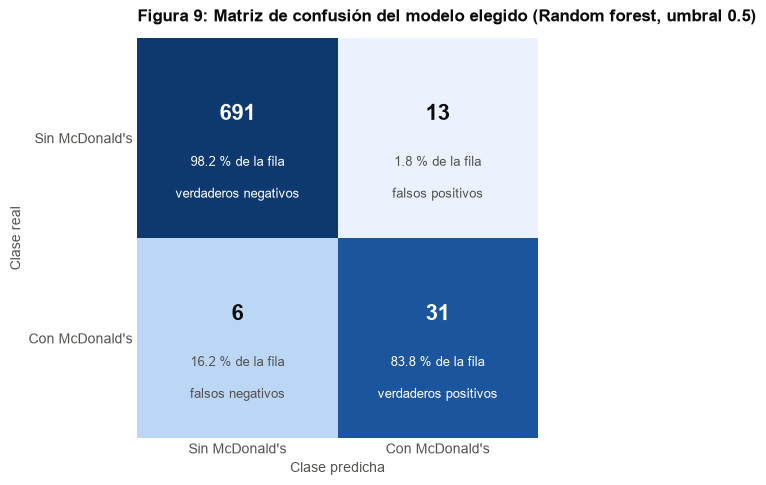

Verdaderos positivos 31 · falsos negativos 6 · falsos positivos 13 · verdaderos negativos 691


In [32]:
modelo_elegido = busquedas[ELEGIDO].best_estimator_
pred_elegido = (prob_prueba[ELEGIDO] >= 0.5).astype(int)
matriz = confusion_matrix(y_pru, pred_elegido)
por_fila = matriz / matriz.sum(axis=1, keepdims=True)
fig, ax = nueva_figura(f"Matriz de confusión del modelo elegido ({ELEGIDO}, umbral 0.5)", (6.4, 5.2))
ax.imshow(por_fila, cmap=CMAP_SEC, vmin=0, vmax=1)
nombres = ["Sin McDonald's", "Con McDonald's"]
descripcion = [["verdaderos negativos", "falsos positivos"], ["falsos negativos", "verdaderos positivos"]]
for i in range(2):
    for j in range(2):
        oscuro = por_fila[i, j] > 0.55
        ax.text(j, i - 0.12, f"{matriz[i, j]:,}", ha="center", va="center", fontsize=16, fontweight="bold",
                color=FONDO if oscuro else TINTA)
        ax.text(j, i + 0.12, f"{100 * por_fila[i, j]:.1f} % de la fila", ha="center", va="center", fontsize=9,
                color=FONDO if oscuro else TINTA_2)
        ax.text(j, i + 0.28, descripcion[i][j], ha="center", va="center", fontsize=9,
                color=FONDO if oscuro else TINTA_2)
ax.set_xticks([0, 1], nombres)
ax.set_yticks([0, 1], nombres)
ax.set_xlabel("Clase predicha")
ax.set_ylabel("Clase real")
ax.tick_params(length=0)
for lado in ax.spines.values():
    lado.set_visible(False)
guardar(fig, "matriz_confusion")
vn, fp, fn, vp = matriz.ravel()
print(f"Verdaderos positivos {vp} · falsos negativos {fn} · falsos positivos {fp} · verdaderos negativos {vn}")

**Importancia de las variables.** La **importancia por permutación** mide cuánto cae el AUC en el conjunto de
prueba cuando se desordenan al azar los valores de una variable (50 repeticiones). Si la caída es grande, el
modelo depende de esa variable. A diferencia de la importancia por impureza, no favorece a las variables con
muchos valores distintos.

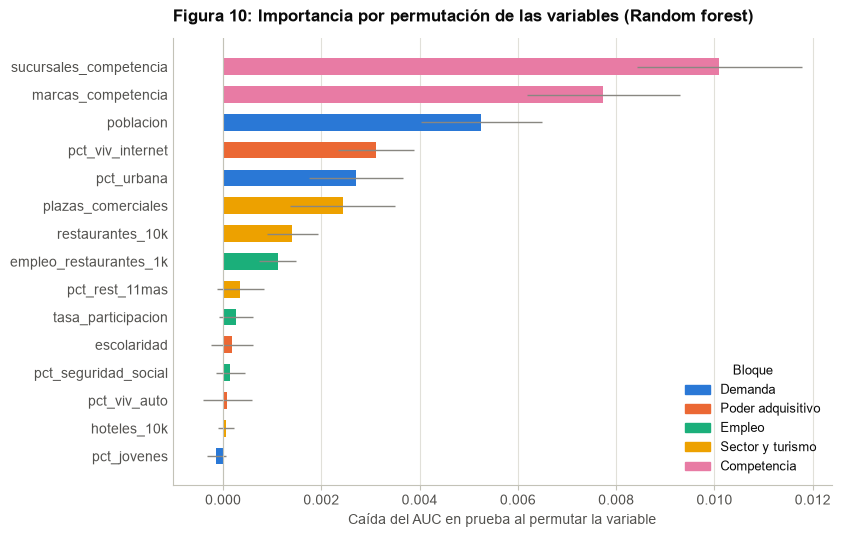

,caída del AUC (media),desv. est.,bloque
sucursales_competencia,0.0101,0.0017,Competencia
marcas_competencia,0.0077,0.0016,Competencia
poblacion,0.0053,0.0012,Demanda
pct_viv_internet,0.0031,0.0008,Poder adquisitivo
pct_urbana,0.0027,0.0010,Demanda
plazas_comerciales,0.0024,0.0011,Sector y turismo
restaurantes_10k,0.0014,0.0005,Sector y turismo
empleo_restaurantes_1k,0.0011,0.0004,Empleo
pct_rest_11mas,0.0004,0.0005,Sector y turismo
tasa_participacion,0.0003,0.0003,Empleo


In [33]:
perm = permutation_importance(modelo_elegido, X_pru, y_pru, scoring="roc_auc", n_repeats=50,
                              random_state=SEMILLA, n_jobs=-1)
importancia = pd.DataFrame({"caída del AUC (media)": perm.importances_mean, "desv. est.": perm.importances_std},
                           index=X_COLS)
importancia["bloque"] = importancia.index.map(BLOQUE_DE)
importancia = importancia.sort_values("caída del AUC (media)")

fig, ax = nueva_figura(f"Importancia por permutación de las variables ({ELEGIDO})", (8.5, 5.8))
ax.barh(importancia.index, importancia["caída del AUC (media)"], xerr=importancia["desv. est."], height=0.6,
        color=[COLOR_BLOQUE[b] for b in importancia.bloque], error_kw={"ecolor": TENUE, "elinewidth": 1})
ax.axvline(0, color=GRIS, linewidth=0.8)
ax.set_xlabel("Caída del AUC en prueba al permutar la variable")
ax.tick_params(axis="y", length=0)
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.legend(handles=[Patch(color=c, label=b) for b, c in COLOR_BLOQUE.items()], loc="lower right", fontsize=9,
          title="Bloque", title_fontsize=9)
guardar(fig, "importancia_permutacion")
display(importancia.sort_values("caída del AUC (media)", ascending=False).round(4))

Las caídas por variable son pequeñas porque las variables están correlacionadas entre sí (sección 2.4): si se
desordena una, otra del mismo bloque aporta casi la misma información y el bosque la sustituye. Para medir el
aporte de cada **factor completo** se permutan juntas todas las variables de un bloque, con la misma permutación
de filas y 50 repeticiones.

In [34]:
rng = np.random.default_rng(SEMILLA)
auc_base = roc_auc_score(y_pru, modelo_elegido.predict_proba(X_pru)[:, 1])
filas = []
for bloque, vs in VARIABLES.items():
    caidas = []
    for _ in range(50):
        X_perm = X_pru.copy()
        X_perm[vs] = X_pru[vs].to_numpy()[rng.permutation(len(X_pru))]
        caidas.append(auc_base - roc_auc_score(y_pru, modelo_elegido.predict_proba(X_perm)[:, 1]))
    filas.append({"bloque": bloque, "variables": len(vs), "caída del AUC (media)": np.mean(caidas),
                  "desv. est.": np.std(caidas)})
importancia_bloque = pd.DataFrame(filas).set_index("bloque").sort_values("caída del AUC (media)", ascending=False)
print(f"AUC del modelo en prueba sin permutar: {auc_base:.3f}")
display(importancia_bloque.round(4))

AUC del modelo en prueba sin permutar: 0.988


,variables,caída del AUC (media),desv. est.
bloque,,,
Competencia,2,0.0261,0.0028
Sector y turismo,4,0.0077,0.0020
Demanda,3,0.0066,0.0017
Poder adquisitivo,3,0.0051,0.0018
Empleo,3,0.0016,0.0007


**Reglas del árbol de decisión (modelo explicativo).** Los cientos de árboles de un bosque no se pueden leer;
un árbol único sí. Sus reglas describen el perfil de los municipios con McDonald's con cortes concretos.

La figura muestra los tres primeros niveles. Como el árbol pondera las clases (`class_weight="balanced"`), los
valores y colores de cada nodo están ponderados. Por eso la tabla siguiente recorre cada hoja y reporta la
proporción **real**, sin ponderar, de municipios con McDonald's en el conjunto de entrenamiento.

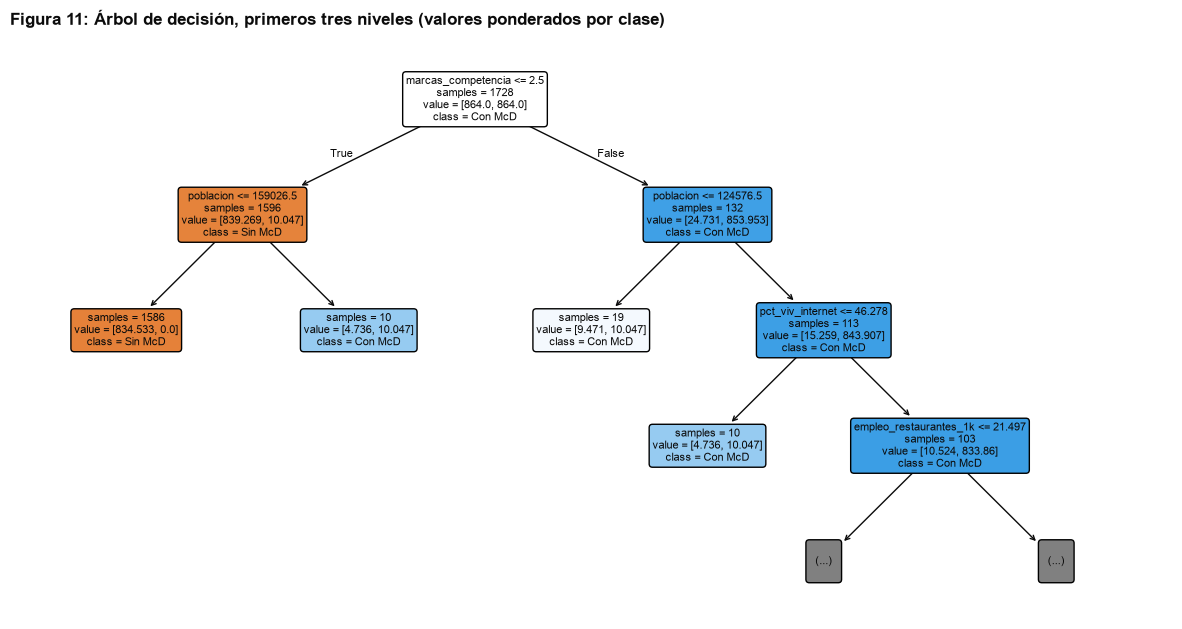

,regla,municipios,con McDonald's,% con McDonald's
0,"marcas_competencia > 2.5 y poblacion > 124,576.5 y pct_viv_internet > 46.3 y empleo_restaurantes_1k > 21.5 y sucursales_competencia > 15.5",45,45,100.0
1,"marcas_competencia > 2.5 y poblacion > 124,576.5 y pct_viv_internet > 46.3 y empleo_restaurantes_1k > 21.5 y sucursales_competencia ≤ 15.5",26,21,80.8
2,"marcas_competencia > 2.5 y poblacion > 124,576.5 y pct_viv_internet > 46.3 y empleo_restaurantes_1k ≤ 21.5 y restaurantes_10k ≤ 44.4",18,13,72.2
3,"marcas_competencia > 2.5 y poblacion > 124,576.5 y pct_viv_internet > 46.3 y empleo_restaurantes_1k ≤ 21.5 y restaurantes_10k > 44.4",14,4,28.6
4,"marcas_competencia > 2.5 y poblacion > 124,576.5 y pct_viv_internet ≤ 46.3",10,1,10.0
5,"marcas_competencia ≤ 2.5 y poblacion > 159,026.5",10,1,10.0
6,"marcas_competencia > 2.5 y poblacion ≤ 124,576.5",19,1,5.3
7,"marcas_competencia ≤ 2.5 y poblacion ≤ 159,026.5",1586,0,0.0


Hojas: 8 · profundidad: 5 · parámetros: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10}


In [35]:
arbol_final = busquedas["Árbol de decisión"].best_estimator_
fig, ax = nueva_figura("Árbol de decisión: primeros tres niveles", (15, 7.5))
plot_tree(arbol_final, max_depth=3, feature_names=X_COLS, class_names=["Sin McD", "Con McD"], filled=True,
          impurity=False, proportion=False, rounded=True, fontsize=8, ax=ax)
ax.set_title(f"Figura {_figura}: Árbol de decisión, primeros tres niveles (valores ponderados por clase)")
guardar(fig, "arbol_decision")


def reglas_del_arbol(arbol, X_ref, y_ref):
    """Una fila por hoja: condiciones del camino, municipios y proporción real con McDonald's."""
    t, hojas, y_arr = arbol.tree_, arbol.apply(X_ref), np.asarray(y_ref)
    filas = []

    def recorrer(nodo, condiciones):
        if t.children_left[nodo] == -1:
            en_hoja = hojas == nodo
            filas.append({"regla": " y ".join(condiciones), "municipios": int(en_hoja.sum()),
                          "con McDonald's": int(y_arr[en_hoja].sum()),
                          "% con McDonald's": 100 * y_arr[en_hoja].mean() if en_hoja.any() else np.nan})
            return
        variable, umbral = X_COLS[t.feature[nodo]], t.threshold[nodo]
        recorrer(t.children_left[nodo], condiciones + [f"{variable} ≤ {umbral:,.1f}"])
        recorrer(t.children_right[nodo], condiciones + [f"{variable} > {umbral:,.1f}"])

    recorrer(0, [])
    return pd.DataFrame(filas).sort_values("% con McDonald's", ascending=False).reset_index(drop=True)


pd.set_option("display.max_colwidth", 160)
reglas = reglas_del_arbol(arbol_final, X_ent, y_ent)
display(reglas.round(1))
pd.set_option("display.max_colwidth", 70)
print(f"Hojas: {len(reglas)} · profundidad: {arbol_final.get_depth()} · parámetros: "
      f"{busquedas['Árbol de decisión'].best_params_}")

**Aporte de cada bloque de variables.** Para medir cuánto aporta cada factor de la hipótesis, el modelo elegido
se reentrena en validación cruzada (conjunto de entrenamiento) de dos formas:

- con **cada bloque por separado**;
- **acumulando bloques** en el orden de la hipótesis.

In [36]:
filas, acumuladas = [], []
for bloque, vs in VARIABLES.items():
    acumuladas = acumuladas + vs
    solo = cross_val_score(clone(modelo_elegido), X_ent[vs], y_ent, cv=CV, scoring="roc_auc", n_jobs=-1)
    acum = cross_val_score(clone(modelo_elegido), X_ent[acumuladas], y_ent, cv=CV, scoring="roc_auc", n_jobs=-1)
    filas.append({"bloque": bloque, "variables": len(vs), "AUC sólo el bloque": solo.mean(),
                  "AUC acumulado": acum.mean()})
aporte = pd.DataFrame(filas).set_index("bloque")
aporte["ganancia al agregarlo"] = aporte["AUC acumulado"].diff().fillna(aporte["AUC acumulado"].iloc[0] - 0.5)
display(aporte.round(3))

,variables,AUC sólo el bloque,AUC acumulado,ganancia al agregarlo
bloque,,,,
Demanda,3,0.991,0.991,0.491
Poder adquisitivo,3,0.973,0.994,0.002
Empleo,3,0.961,0.995,0.001
Sector y turismo,4,0.990,0.995,0.000
Competencia,2,0.990,0.996,0.001


**Ranking de oportunidades.** Para calificar a los 2,469 municipios sin que ninguno sea calificado por un modelo
que ya lo vio, se calculan **probabilidades fuera de pliegue**:

- validación cruzada de 5 pliegues, repetida 5 veces con distintas particiones;
- cada municipio recibe el promedio de las 5 probabilidades que obtuvo mientras estaba fuera del
  entrenamiento.

Entre los municipios **sin** sucursal, un falso positivo del modelo no es un error: es un municipio con perfil
de McDonald's donde la marca no está, es decir, una oportunidad.

Cada candidato se clasifica según la distancia entre su localidad principal y la del municipio con McDonald's
más cercano:

- **densificación** si está a menos de 30 km;
- **mercado nuevo** si está más lejos.

In [37]:
REPETICIONES = 5
prob_oof = np.zeros(len(X))
for r in range(REPETICIONES):
    pliegues = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA + r)
    for idx_ent, idx_pru in pliegues.split(X, y):
        m = clone(modelo_elegido).fit(X.iloc[idx_ent], y.iloc[idx_ent])
        prob_oof[idx_pru] += m.predict_proba(X.iloc[idx_pru])[:, 1] / REPETICIONES
tabla["probabilidad"] = prob_oof
grandes = (tabla.poblacion >= 100_000).to_numpy()
print(f"AUC de las probabilidades fuera de pliegue sobre los 2,469 municipios: {roc_auc_score(y, prob_oof):.3f}")
print(f"AUC fuera de pliegue sólo en los {grandes.sum()} municipios de 100 mil habitantes o más "
      f"({int(y[grandes].sum())} con McDonald's): {roc_auc_score(y[grandes], prob_oof[grandes]):.3f}")

con_mcd = tabla[tabla.tiene_mcdonalds == 1]
lat_c, lon_c = con_mcd.latitud.to_numpy(), con_mcd.longitud.to_numpy()
tabla["km_mcdonalds_cercano"] = [
    0.0 if t else float(np.min(km_entre(la, lo, lat_c, lon_c)))
    for la, lo, t in zip(tabla.latitud, tabla.longitud, tabla.tiene_mcdonalds)]
tabla["tipo_oportunidad"] = np.where(tabla.tiene_mcdonalds == 1, "Ya tiene McDonald's",
                                     np.where(tabla.km_mcdonalds_cercano < 30, "Densificación", "Mercado nuevo"))
sin_mcd = tabla[tabla.tiene_mcdonalds == 0].sort_values("probabilidad", ascending=False)
tabla["rango_oportunidad"] = pd.Series(np.arange(1, len(sin_mcd) + 1), index=sin_mcd.index)

top20 = sin_mcd.head(20).copy()
top20.insert(0, "rango", range(1, 21))
COLS_TOP = ["rango", "entidad", "municipio", "probabilidad", "tipo_oportunidad", "km_mcdonalds_cercano", "poblacion",
            "escolaridad", "pct_viv_auto", "marcas_competencia", "sucursales_competencia", "plazas_comerciales"]
display(top20[COLS_TOP].round(2))
print(top20.tipo_oportunidad.value_counts().to_string())

(tabla[["entidad", "municipio", "localidad_principal", "latitud", "longitud", "poblacion", "sucursales_mcdonalds",
        "tiene_mcdonalds", "probabilidad", "rango_oportunidad", "tipo_oportunidad", "km_mcdonalds_cercano"]]
 .sort_values("probabilidad", ascending=False)
 .to_csv(ANALITICOS / "predicciones_municipios.csv", encoding="utf-8-sig"))

AUC de las probabilidades fuera de pliegue sobre los 2,469 municipios: 0.993
AUC fuera de pliegue sólo en los 235 municipios de 100 mil habitantes o más (116 con McDonald's): 0.922


,rango,entidad,municipio,probabilidad,tipo_oportunidad,km_mcdonalds_cercano,poblacion,escolaridad,pct_viv_auto,marcas_competencia,sucursales_competencia,plazas_comerciales
clave_mun,,,,,,,,,,,,
18017,1,Nayarit,Tepic,0.99,Mercado nuevo,92.18,425924,11.17,52.60,7,22,14
19006,2,Nuevo León,Apodaca,0.99,Densificación,10.46,656464,11.35,66.69,7,37,33
04002,3,Campeche,Campeche,0.99,Mercado nuevo,157.11,294077,10.72,41.85,5,13,22
14098,4,Jalisco,San Pedro Tlaquepaque,0.99,Densificación,5.56,687127,10.18,55.05,7,24,32
22006,5,Querétaro,Corregidora,0.98,Densificación,7.39,212567,12.22,76.59,5,15,62
06007,6,Colima,Manzanillo,0.98,Mercado nuevo,65.29,191031,10.11,48.38,8,10,12
06010,7,Colima,Villa de Álvarez,0.96,Densificación,2.59,149762,11.56,62.73,7,9,11
15039,8,México,Ixtapaluca,0.95,Densificación,5.90,542211,10.14,36.55,5,12,15
08021,9,Chihuahua,Delicias,0.95,Mercado nuevo,77.07,150506,10.20,69.76,5,8,17


tipo_oportunidad
Densificación    14
Mercado nuevo     6


**Validación externa del ranking.** El DENUE es una fotografía con rezago, y el caso Michoacán mostró que
puede omitir sucursales. Por eso cada uno de los 20 candidatos se buscó en el sitio oficial de la marca
(`mcdonalds.com.mx`, páginas de sucursal y listas de restaurantes participantes). Cuando hubo aperturas o
cierres recientes, también se consultó la prensa. Fecha de consulta: 19 de septiembre de 2026.

Cada candidato recibe uno de tres resultados:

- **Ya tiene McDonald's.** Existe una página oficial de sucursal dentro del municipio: es una sucursal real
  que el DENUE no registra, por ser reciente o por estar capturada con otro nombre.
- **No concluyente.** La sucursal oficial está en el límite con otro municipio y el sitio la asigna a ese
  otro municipio.
- **Sin evidencia de sucursal.** No se encontró ninguna página oficial. No prueba la ausencia; es el
  candidato que pasa a verificación de campo.

In [38]:
FUENTE_COLIMA = ("https://www.colimanoticias.com/cadenas-y-franquicias-que-se-han-ido-de-colima-por-inseguridad-"
                 "economias-fluctuantes-y-nuevas-empresas/")
SIN_PAGINA = "Sin página de sucursal en mcdonalds.com.mx"
VALIDACION_EXTERNA = pd.DataFrame([
    ("18017", "Sin evidencia de sucursal", SIN_PAGINA, ""),
    ("19006", "Ya tiene McDonald's", "Plaza Citadina (Av. Concordia 801), abierta en noviembre de 2025",
     "https://www.mcdonalds.com.mx/restaurantes/monterrey-nl/plaza-citadina-994"),
    ("04002", "Ya tiene McDonald's", "Campeche F.S. (Av. Román Piña Chan 5)",
     "https://www.mcdonalds.com.mx/restaurantes/campeche"),
    ("14098", "No concluyente", "Forum Tlaquepaque: el sitio oficial la asigna a Guadalajara",
     "https://www.mcdonalds.com.mx/restaurantes/guadalajara/forum-tlaquepaque-762"),
    ("22006", "Sin evidencia de sucursal", SIN_PAGINA + "; las de la zona metropolitana están en Querétaro", ""),
    ("06007", "Sin evidencia de sucursal", SIN_PAGINA + "; la marca cerró en la ciudad de Colima en mayo de 2025",
     FUENTE_COLIMA),
    ("06010", "Sin evidencia de sucursal", SIN_PAGINA + "; conurbado con Colima, donde la marca cerró en 2025",
     FUENTE_COLIMA),
    ("15039", "Ya tiene McDonald's", "Carretera México-Puebla y Av. Cuauhtémoc (Col. Santa Bárbara)",
     "https://www.mcdonalds.com.mx/restaurantes/estado-de-mexico/mcdonalds-carretera-mx-puebla-927"),
    ("08021", "Sin evidencia de sucursal", SIN_PAGINA, ""),
    ("09013", "Sin evidencia de sucursal", SIN_PAGINA, ""),
    ("24035", "Sin evidencia de sucursal", SIN_PAGINA + "; las de la zona metropolitana están en San Luis Potosí", ""),
    ("26055", "Sin evidencia de sucursal", SIN_PAGINA, ""),
    ("14101", "No concluyente", "Río Nilo: el sitio oficial la asigna a Guadalajara; la avenida cruza ambos municipios",
     "https://www.mcdonalds.com.mx/restaurantes/guadalajara/guadalajara-rio-nilo-517"),
    ("19031", "Sin evidencia de sucursal", SIN_PAGINA, ""),
    ("30131", "Sin evidencia de sucursal", SIN_PAGINA, ""),
    ("13069", "Sin evidencia de sucursal", SIN_PAGINA, ""),
    ("15060", "Sin evidencia de sucursal", SIN_PAGINA, ""),
    ("11027", "Sin evidencia de sucursal", SIN_PAGINA, ""),
    ("15109", "Ya tiene McDonald's", "Tultitlán (Av. Prados esq. Praderas, San Pablo de las Salinas)",
     "https://www.mcdonalds.com.mx/restaurantes/estado-de-mexico/tultitlan-997"),
    ("15099", "Ya tiene McDonald's", "Patio Texcoco (Av. Hidalgo 300) y Texcoco San Pablo (Juárez Norte 304)",
     "https://cupones.mcdonalds.com.mx/restaurantes-participantes-mx"),
], columns=["clave_mun", "estado", "evidencia", "fuente"]).set_index("clave_mun")
assert set(VALIDACION_EXTERNA.index) == set(top20.index), "El ranking cambió: hay que repetir la validación"

top20 = top20.join(VALIDACION_EXTERNA)
pd.set_option("display.max_colwidth", 95)
display(top20[["rango", "entidad", "municipio", "probabilidad", "estado", "evidencia"]].round(2))
pd.set_option("display.max_colwidth", 70)
print(top20.estado.value_counts().to_string())
(top20[["rango", "entidad", "municipio", "probabilidad", "tipo_oportunidad", "estado", "evidencia", "fuente"]]
 .assign(fecha_consulta="2026-09-19")
 .to_csv(ANALITICOS / "validacion_externa_top20.csv", encoding="utf-8-sig"))

oportunidades = top20[top20.estado == "Sin evidencia de sucursal"].copy()
print(f"\nOportunidades depuradas (sin evidencia de sucursal): {len(oportunidades)}")
display(oportunidades[["rango", "entidad", "municipio", "probabilidad", "tipo_oportunidad", "km_mcdonalds_cercano",
                       "poblacion", "escolaridad", "marcas_competencia", "plazas_comerciales"]].round(2))

,rango,entidad,municipio,probabilidad,estado,evidencia
clave_mun,,,,,,
18017,1,Nayarit,Tepic,0.99,Sin evidencia de sucursal,Sin página de sucursal en mcdonalds.com.mx
19006,2,Nuevo León,Apodaca,0.99,Ya tiene McDonald's,"Plaza Citadina (Av. Concordia 801), abierta en noviembre de 2025"
04002,3,Campeche,Campeche,0.99,Ya tiene McDonald's,Campeche F.S. (Av. Román Piña Chan 5)
14098,4,Jalisco,San Pedro Tlaquepaque,0.99,No concluyente,Forum Tlaquepaque: el sitio oficial la asigna a Guadalajara
22006,5,Querétaro,Corregidora,0.98,Sin evidencia de sucursal,Sin página de sucursal en mcdonalds.com.mx; las de la zona metropolitana están en Querétaro
06007,6,Colima,Manzanillo,0.98,Sin evidencia de sucursal,Sin página de sucursal en mcdonalds.com.mx; la marca cerró en la ciudad de Colima en mayo d...
06010,7,Colima,Villa de Álvarez,0.96,Sin evidencia de sucursal,"Sin página de sucursal en mcdonalds.com.mx; conurbado con Colima, donde la marca cerró en 2025"
15039,8,México,Ixtapaluca,0.95,Ya tiene McDonald's,Carretera México-Puebla y Av. Cuauhtémoc (Col. Santa Bárbara)
08021,9,Chihuahua,Delicias,0.95,Sin evidencia de sucursal,Sin página de sucursal en mcdonalds.com.mx


estado
Sin evidencia de sucursal    13
Ya tiene McDonald's           5
No concluyente                2

Oportunidades depuradas (sin evidencia de sucursal): 13


,rango,entidad,municipio,probabilidad,tipo_oportunidad,km_mcdonalds_cercano,poblacion,escolaridad,marcas_competencia,plazas_comerciales
clave_mun,,,,,,,,,,
18017,1,Nayarit,Tepic,0.99,Mercado nuevo,92.18,425924,11.17,7,14
22006,5,Querétaro,Corregidora,0.98,Densificación,7.39,212567,12.22,5,62
06007,6,Colima,Manzanillo,0.98,Mercado nuevo,65.29,191031,10.11,8,12
06010,7,Colima,Villa de Álvarez,0.96,Densificación,2.59,149762,11.56,7,11
08021,9,Chihuahua,Delicias,0.95,Mercado nuevo,77.07,150506,10.20,5,17
09013,10,Ciudad de México,Xochimilco,0.95,Densificación,7.09,442178,10.84,5,9
24035,11,San Luis Potosí,Soledad de Graciano Sánchez,0.94,Densificación,5.74,332072,10.68,8,4
26055,12,Sonora,San Luis Río Colorado,0.94,Mercado nuevo,67.65,199021,9.46,6,9
19031,14,Nuevo León,Juárez,0.92,Densificación,17.29,471523,9.88,4,8


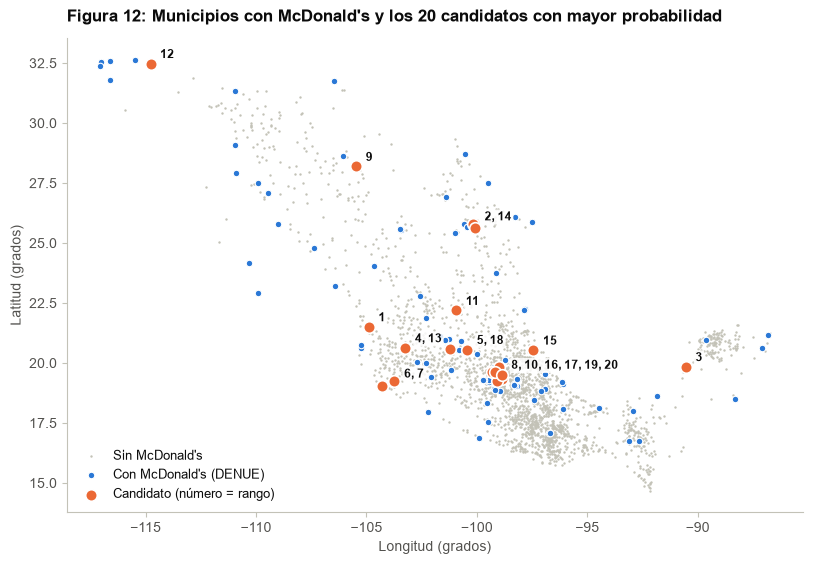

In [39]:
fig, ax = nueva_figura("Municipios con McDonald's y los 20 candidatos con mayor probabilidad", (9.5, 6.6))
ax.scatter(tabla.longitud, tabla.latitud, s=3, color=GRIS, linewidths=0, label="Sin McDonald's")
ax.scatter(con_mcd.longitud, con_mcd.latitud, s=22, color=AZUL, edgecolors=FONDO, linewidths=0.8,
           label="Con McDonald's (DENUE)")
ax.scatter(top20.longitud, top20.latitud, s=70, color=NARANJA, edgecolors=FONDO, linewidths=1.2,
           label="Candidato (número = rango)", zorder=3)
# Los candidatos a menos de 90 km entre sí comparten una sola etiqueta para que no se encimen.
grupos = []
for _, fila in top20.sort_values("rango").iterrows():
    for grupo in grupos:
        if any(km_entre(fila.latitud, fila.longitud, o.latitud, o.longitud) < 90 for o in grupo):
            grupo.append(fila)
            break
    else:
        grupos.append([fila])
for grupo in grupos:
    ax.annotate(", ".join(str(f.rango) for f in grupo),
                (max(f.longitud for f in grupo), np.mean([f.latitud for f in grupo])),
                xytext=(7, 4), textcoords="offset points", fontsize=8.5, fontweight="bold", color=TINTA,
                bbox={"boxstyle": "round,pad=0.15", "facecolor": FONDO, "edgecolor": "none", "alpha": 0.85},
                zorder=4)
ax.set_aspect(1 / np.cos(np.radians(23)))
ax.set_xlabel("Longitud (grados)")
ax.set_ylabel("Latitud (grados)")
ax.legend(loc="lower left", fontsize=9, markerscale=1)
guardar(fig, "mapa_candidatos")

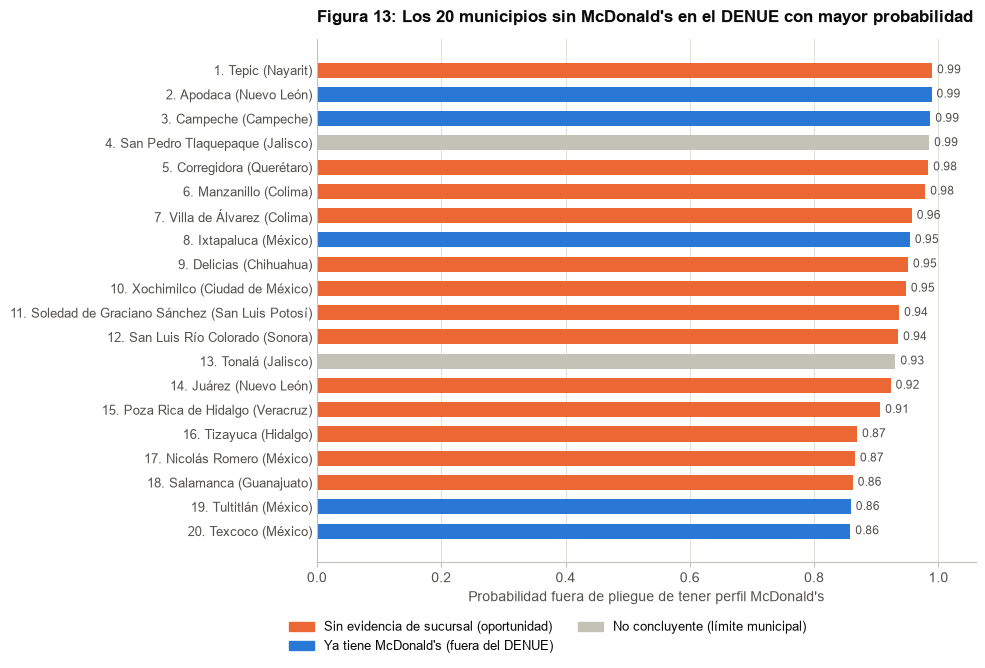

In [40]:
orden_top = top20.sort_values("probabilidad")
COLOR_ESTADO = {"Sin evidencia de sucursal": NARANJA, "Ya tiene McDonald's": AZUL, "No concluyente": GRIS}
fig, ax = nueva_figura("Los 20 municipios sin McDonald's en el DENUE con mayor probabilidad", (8.5, 6.8))
etiquetas = [f"{r}. {m} ({CORTOS.get(e, e)})" for r, m, e in zip(orden_top.rango, orden_top.municipio,
                                                                 orden_top.entidad)]
ax.barh(etiquetas, orden_top.probabilidad, height=0.62, color=[COLOR_ESTADO[s] for s in orden_top.estado])
for i, p in enumerate(orden_top.probabilidad):
    ax.text(p + 0.008, i, f"{p:.2f}", va="center", fontsize=8.5, color=TINTA_2)
ax.set_xlabel("Probabilidad fuera de pliegue de tener perfil McDonald's")
ax.set_xlim(0, 1.06)
ax.tick_params(axis="y", length=0, labelsize=9)
ax.grid(axis="x")
ax.set_axisbelow(True)
ax.legend(handles=[Patch(color=COLOR_ESTADO["Sin evidencia de sucursal"], label="Sin evidencia de sucursal (oportunidad)"),
                   Patch(color=COLOR_ESTADO["Ya tiene McDonald's"], label="Ya tiene McDonald's (fuera del DENUE)"),
                   Patch(color=COLOR_ESTADO["No concluyente"], label="No concluyente (límite municipal)")],
          loc="upper center", bbox_to_anchor=(0.35, -0.09), ncol=2, fontsize=9)
guardar(fig, "top20_candidatos")

In [41]:
estratos = sucursales.groupby("clave_2020").per_ocu.agg(lambda s: ", ".join(sorted(s.unique())))
atipicos = (tabla[tabla.tiene_mcdonalds == 1].sort_values("probabilidad")
            [["entidad", "municipio", "probabilidad", "poblacion", "sucursales_mcdonalds"]].head(8).copy())
atipicos["personal de sus sucursales"] = estratos.reindex(atipicos.index)
print("Municipios CON McDonald's que el modelo considera atípicos (menor probabilidad fuera de pliegue):")
display(atipicos.round(3))

Municipios CON McDonald's que el modelo considera atípicos (menor probabilidad fuera de pliegue):


,entidad,municipio,probabilidad,poblacion,sucursales_mcdonalds,personal de sus sucursales
clave_mun,,,,,,
15019,México,Capulhuac,0.054,36921,1,0 a 5 personas
20184,Oaxaca,San Juan Bautista Tuxtepec,0.140,159452,1,0 a 5 personas
29002,Tlaxcala,Apetatitlán de Antonio Carvajal,0.143,16003,1,11 a 30 personas
29010,Tlaxcala,Chiautempan,0.214,73215,1,51 a 100 personas
15062,México,Ocoyoacac,0.233,72103,1,31 a 50 personas
16076,Michoacán de Ocampo,Sahuayo,0.454,78477,1,31 a 50 personas
21034,Puebla,Coronango,0.464,46836,1,31 a 50 personas
20390,Oaxaca,Santa Lucía del Camino,0.548,50362,1,11 a 30 personas


### Interpretación de los resultados

**Desempeño**

- **El random forest es el modelo de puntuación.** Obtuvo el mayor AUC en validación cruzada (0.996 ± 0.003)
  y lo confirma en prueba (0.988).
  - Naive Bayes queda prácticamente empatado en prueba (0.986): con 37 positivos, esa diferencia es ruido.
  - El árbol único cae a 0.924, porque sus 8 hojas producen probabilidades gruesas.
- **Con el umbral de 0.5, el bosque:**
  - detecta 31 de los 37 municipios con McDonald's del conjunto de prueba (exhaustividad de 0.84);
  - acierta en 31 de los 44 municipios que señala (precisión de 0.70);
  - clasifica correctamente al 98 % de los municipios sin sucursal.
- **El AUC tan alto se explica en parte porque la mayoría de los casos son fáciles.** La hoja más grande del
  árbol, con menos de tres cadenas rivales y menos de 159 mil habitantes, reúne 1,586 de los 1,728 municipios de
  entrenamiento, y ninguno tiene McDonald's. El problema de negocio está en las ciudades: entre los 235
  municipios de 100 mil habitantes o más, el AUC fuera de pliegue es **0.922**. Esa cifra es la medida realista
  de lo que el modelo discrimina.

**Qué explica la presencia de McDonald's**

- **Por variable.** La permutación muestra que el bosque se apoya, en este orden, en:
  1. la competencia (sucursales y marcas rivales);
  2. la población;
  3. el internet en la vivienda;
  4. la urbanización;
  5. las plazas comerciales.
- **Por bloque.**
  - Al permutar bloques completos, la **competencia** es el factor con más información propia (caída de 0.026
    en el AUC).
  - Por sí solo, el bloque de **demanda** alcanza un AUC de 0.991.
  - Los demás bloques añaden poco una vez que están la demanda y la competencia: el AUC acumulado pasa de 0.991
    a 0.996. Sus variables cuentan la misma historia desde otro ángulo.
- **Reglas del árbol.** Traducen el perfil a lenguaje de negocio. Los 45 municipios de entrenamiento que
  cumplen las cinco condiciones siguientes tienen McDonald's en el **100 %** de los casos:
  1. más de dos marcas rivales;
  2. más de 124,577 habitantes;
  3. internet en más del 46.3 % de las viviendas;
  4. más de 21.5 empleos en restaurantes por cada mil habitantes;
  5. más de 15 sucursales rivales.
- **Hay una salvedad.** La competencia no *causa* la presencia de McDonald's: las cadenas rivales siguen la
  misma lógica de ubicación. Su valor es de señal: donde ya operan Burger King, KFC o Starbucks, el mercado ya
  está probado.

**Oportunidades**

- **Los 20 candidatos son en su mayoría densificación.**
  - Catorce están a menos de 30 km de una sucursal: son municipios de zonas metropolitanas (Valle de México,
    Monterrey, Guadalajara, Querétaro, San Luis Potosí) donde la marca sólo está en el municipio central.
  - Seis son mercados nuevos: Tepic, Campeche, Manzanillo, Delicias, San Luis Río Colorado y Poza Rica.
- **La validación externa respalda al modelo.**
  - Cinco candidatos ya tienen un McDonald's que el DENUE no registra: Apodaca, Campeche, Ixtapaluca,
    Tultitlán y Texcoco. Apodaca abrió en noviembre de 2025, y varias de esas sucursales tienen números de
    tienda de la serie 900, típicos de aperturas recientes.
  - En otras palabras, el modelo encontró por sí solo municipios donde la empresa decidió abrir hace poco.
  - Quedan **13 oportunidades depuradas**, sin evidencia de sucursal.
- **Anomalías: municipios con sucursal y baja probabilidad.** Son pequeños (Capulhuac, Apetatitlán, Ocoyoacac)
  o tienen registros de 0 a 5 empleados, un tamaño atípico para la marca. Algunos son sucursales reales en
  mercados pequeños; Tuxtepec, por ejemplo, tiene página oficial de sucursal. Otros pueden ser errores de
  captura. Para el negocio son las ubicaciones que no siguen el patrón general: casos para revisar su
  desempeño.

---
## 4. Consideraciones del modelo

### 4.1 Beneficios

1. **Criba nacional con datos gratuitos y reproducibles.**
   - Reduce 2,469 municipios a una lista corta en minutos.
   - Se puede repetir con cada nueva edición del DENUE: basta con reemplazar los ZIP de `datos/crudos/`.
2. **Prioriza el gasto en estudios de sitio.** Las visitas de campo, los aforos y la búsqueda de predios se
   concentran en 13 municipios en lugar de cientos.
3. **Es explicable.** Las reglas del árbol y la importancia por bloque dicen *por qué* un municipio es
   candidato. Eso facilita la discusión con el comité de expansión.
4. **Evaluación honesta.**
   - Los parámetros se eligen sólo con el conjunto de entrenamiento.
   - La prueba se reserva para confirmar.
   - El ranking usa probabilidades fuera de pliegue, así que ningún municipio es calificado por un modelo que
     lo vio.
5. **Mejora la calidad de los datos del negocio.** El contraste del modelo con fuentes externas reveló:
   - un franquiciatario invisible en el DENUE (Michoacán);
   - cinco sucursales recientes aún no registradas;
   - un cierre (Colima) que el directorio todavía no refleja.
6. **Incorpora el ámbito laboral.** Mide la afiliación a la seguridad social y el empleo del sector
   restaurantero, y estima el personal ocupado de la propia marca (unas 14,400 personas).

### 4.2 Limitaciones

1. **La etiqueta es la decisión pasada de la empresa, no la rentabilidad.** El modelo aprende "dónde está
   McDonald's", no "dónde sería rentable". Un municipio sin sucursal pudo descartarse por razones que los datos
   no ven: seguridad, disponibilidad de predios, logística de abasto o acuerdos con franquiciatarios.
2. **La etiqueta tiene ruido.**
   - El DENUE omite sucursales recientes y registradas con otro nombre (validación externa del top 20).
   - Conserva al menos una sucursal cerrada (Colima).
   - La regla de identificación por texto puede tener errores residuales en ambos sentidos.
3. **Hay desfase temporal.** El censo es de 2020 y el DENUE de 2026. Los municipios que crecieron rápido
   después de 2020 (corredores industriales, zonas turísticas nuevas) aparecen con su perfil anterior.
4. **La unidad municipal es gruesa.** Una alcaldía de 1.8 millones de habitantes cuenta igual que un
   municipio de 40 mil, y el modelo no dice en qué calle ni en qué plaza abrir.
5. **La competencia es endógena.** Las cadenas rivales y McDonald's eligen sus ubicaciones con criterios
   parecidos. La variable sirve para predecir, no para explicar causas.
6. **La clase positiva es pequeña.** Con 123 municipios positivos y 37 en prueba, las métricas de prueba
   tienen varianza. Por eso se reporta también la validación cruzada y el AUC fuera de pliegue.
7. **No hay datos de ventas, tráfico ni ingreso.** El censo no pregunta el ingreso de los hogares; el poder
   adquisitivo se aproxima con escolaridad, internet y automóvil.
8. **La validación externa es parcial.** La ausencia de página oficial no prueba que no haya sucursal, y sólo
   se validaron los 20 primeros candidatos.

### 4.3 Supuestos

1. El DENUE 05/2026 representa razonablemente las sucursales activas; las omisiones detectadas son la
   excepción.
2. Un municipio con McDonald's es un mercado validado por la empresa: la etiqueta positiva equivale a un buen
   mercado.
3. La estructura socioeconómica relativa de los municipios no cambió de forma importante entre 2020 y 2026.
4. El personal ocupado de cada estrato es el punto medio del estrato, y el estrato abierto "251 y más" vale
   251.
5. Cada municipio creado después de 2020 equivale, para el análisis, al municipio del que se separó.
6. Los municipios son independientes entre sí. Se ignora la autocorrelación espacial: dos municipios vecinos
   comparten mercado, y por eso muchos candidatos son de densificación.
7. Naive Bayes supone independencia condicional entre variables. No se cumple (sección 2.4), así que se usa
   sólo como línea base.

---
## 5. Conclusiones

**Respuesta a la hipótesis: H1 se sostiene.** Se cumplen los tres criterios fijados antes de modelar.

| Criterio | Umbral | Resultado | ¿Se cumple? |
|---|---|---|---|
| AUC del mejor modelo en prueba | ≥ 0.80 | 0.988 (0.922 en municipios de 100 mil hab. o más) | Sí |
| Demanda y poder adquisitivo entre las variables más importantes | Entre las primeras | Población 3.ª, internet 4.ª y urbanización 5.ª, detrás de las dos variables de competencia; el bloque de demanda por sí solo da AUC 0.991 | Sí |
| Diferencias significativas entre grupos | Mayoría de las variables | 15 de 15 con p < 0.05 | Sí |

La presencia de McDonald's no es aleatoria. La explican, en ese orden:

1. el **tamaño y la urbanización del mercado**;
2. la **presencia de cadenas rivales**;
3. el **poder adquisitivo** de los hogares.

El empleo formal y la actividad restaurantera acompañan el patrón, pero aportan poca información adicional.

**Recomendaciones para el equipo de expansión**

1. **Abrir estudio de sitio en Tepic como prioridad de mercado nuevo.** Es una capital estatal de 426 mil
   habitantes, con 7 de las 8 cadenas rivales presentes y a 92 km de la sucursal más cercana. Es el candidato
   con mayor probabilidad y no tiene sucursal según el sitio oficial.
2. **Densificar zonas metropolitanas y corredores donde la marca ya opera cerca:**
   - Corregidora, en Querétaro (la escolaridad más alta de la lista: 12.2 años);
   - Soledad de Graciano Sánchez, en San Luis Potosí (las 8 cadenas rivales presentes);
   - Juárez, en Nuevo León;
   - Xochimilco, en la Ciudad de México;
   - Nicolás Romero, en el Estado de México;
   - Tizayuca, en Hidalgo;
   - Salamanca, en Guanajuato, a 19 km de Irapuato.

   Suman más de 2.3 millones de habitantes y comparten logística con sucursales existentes.
3. **Evaluar como mercados nuevos:** Delicias, San Luis Río Colorado y Poza Rica. Son ciudades medias con
   competencia instalada, a más de 65 km de la sucursal más cercana.
4. **Tratar Colima con cautela.** Manzanillo y Villa de Álvarez tienen el perfil, pero la marca cerró su
   restaurante de la capital en 2025. Esa era la sucursal de referencia de Villa de Álvarez, que en realidad
   es hoy un mercado nuevo. Antes de volver hay que entender por qué salió: seguridad y economía local,
   variables que el modelo no mide.
5. **Institucionalizar el ciclo.** Hay que actualizar el modelo con cada edición del DENUE y alimentar la
   etiqueta con la lista oficial de sucursales en lugar de la búsqueda por texto. Eso elimina el ruido
   detectado y convierte la criba en un tablero permanente de expansión.

**Siguientes pasos analíticos**

- Bajar de municipio a AGEB urbana o a una malla de 1 km para ubicar plazas y avenidas concretas.
- Incorporar el ingreso de la ENIGH y la inseguridad del SESNSP.
- Modelar el número de sucursales (regresión de conteo), no sólo su presencia.

In [42]:
resumen = pd.DataFrame([
    ("Municipios analizados", f"{len(tabla):,}"),
    ("Sucursales de McDonald's identificadas", f"{n_suc} en {n_mun} municipios"),
    ("Variables explicativas", f"{len(X_COLS)} en 5 bloques"),
    ("Modelo elegido", ELEGIDO),
    ("AUC en validación cruzada", f"{auc_cv[ELEGIDO]:.3f}"),
    ("AUC en prueba", f"{desempeno.loc[ELEGIDO, 'AUC ROC']:.3f}"),
    ("AUC fuera de pliegue, municipios de 100 mil hab. o más", f"{roc_auc_score(y[grandes], prob_oof[grandes]):.3f}"),
    ("Variables con diferencia significativa", f"{significativas} de {len(X_COLS)}"),
    ("Candidatos del top 20 que ya tienen McDonald's (validación externa)",
     f"{(top20.estado == 'Ya tiene McDonald' + chr(39) + 's').sum()} de 20"),
    ("Oportunidades depuradas", f"{len(oportunidades)} de 20"),
    ("Oportunidad número 1", f"{oportunidades.iloc[0].municipio}, {oportunidades.iloc[0].entidad} "
                             f"(probabilidad {oportunidades.iloc[0].probabilidad:.2f})"),
], columns=["Indicador", "Resultado"])
pd.set_option("display.max_colwidth", 90)
display(resumen)

,Indicador,Resultado
0,Municipios analizados,"2,469"
1,Sucursales de McDonald's identificadas,417 en 123 municipios
2,Variables explicativas,15 en 5 bloques
3,Modelo elegido,Random forest
4,AUC en validación cruzada,0.996
5,AUC en prueba,0.988
6,"AUC fuera de pliegue, municipios de 100 mil hab. o más",0.922
7,Variables con diferencia significativa,15 de 15
8,Candidatos del top 20 que ya tienen McDonald's (validación externa),5 de 20
9,Oportunidades depuradas,13 de 20


---
### Referencias

- INEGI (2026). *Directorio Estadístico Nacional de Unidades Económicas (DENUE) 05/2026*, sector 72. Descarga
  masiva: https://www.inegi.org.mx/app/descarga/?ti=6
- INEGI (2021, actualizado en 2022). *Censo de Población y Vivienda 2020. Principales resultados por localidad
  (ITER)*. https://www.inegi.org.mx/programas/ccpv/2020/
- Expansión (14 de agosto de 2026). *McDonald's ya tiene 380 sucursales en México y quiere abrir más: ya usa IA
  para saber dónde ponerlas.*
  https://expansion.mx/empresas/2026/08/14/mcdonalds-380-sucursales-abrir-mas-mexico
- ABC Noticias (25 de noviembre de 2025). *McDonald's inaugura su primera sucursal en Apodaca.*
  https://abcnoticias.mx/local/2025/11/25/mcdonalds-inaugura-su-primera-sucursal-en-apodaca-266740.html
- Colima Noticias (11 de agosto de 2025). *Cadenas y franquicias que se han ido de Colima.*
  https://www.colimanoticias.com/cadenas-y-franquicias-que-se-han-ido-de-colima-por-inseguridad-economias-fluctuantes-y-nuevas-empresas/
- McDonald's México. Localizador de restaurantes y páginas de sucursal (consulta del 19 de septiembre de 2026).
  https://www.mcdonalds.com.mx/restaurantes
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research,
  12, 2825-2830.